Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°6**
**Tema**: Aplicaciones de AG - Tachos

**Integrantes**:
- Adrián Holgado
- Alvaro Toledo
- Matias Longhino

## Ejercicio 1
Se tiene el siguiente modelo simplificado del funcionamiento de un sector de una fábrica de azúcar: Se tienen **N** tachos de cocimiento, cada uno de los cuales consume vapor de una determinada manera a lo largo del tiempo. El consumo total de vapor puede calcularse como la suma del consumo de vapor individual de cada tacho. El tiempo entre que empieza a consumir el primer tacho hasta que deja de consumir el último tacho es **tMAX** (llamado tiempo total del ciclo o *timespan*). Durante este tiempo, el consumo de vapor varía en el tiempo, consumiendo mayor energía mientras mayor sea esta variación. Este problema consiste en reducir la energía que se consume por la variación de vapor a lo largo del ciclo de cocimiento de la azúcar. A continuación se brindan detalles del modelado del problema:


Un tacho de cocimiento consume vapor durante un lapso de tiempo. El proceso arranca en el tiempo t0, y finaliza en t1 = t0+1 donde ya se consumió todo el vapor del tacho. Es decir, el proceso dura *una unidad de tiempo*. Este comportamiento se puede modelar como una parábola con las ramas hacia abajo, donde alcanza su máximo en t = 1, y está definida en el intervalo  t0 ≤ t ≤ t0+1, siendo nulo fuera de dicho intervalo. Es decir:

  * VaporTacho_i(t) = **0**, *si 0 ≤ t ≤ t0*
  * VaporTacho_i(t) = **1 - (2 * t0 - 2t + 1)^2**, *si t0 ≤ t ≤ t0+1*
  * VaporTacho_i(t) = **0**, *si t1 ≤ t ≤ tMAX*








Consumo de vapor para un tacho, tomando como ejemplo t0 = 1.000000


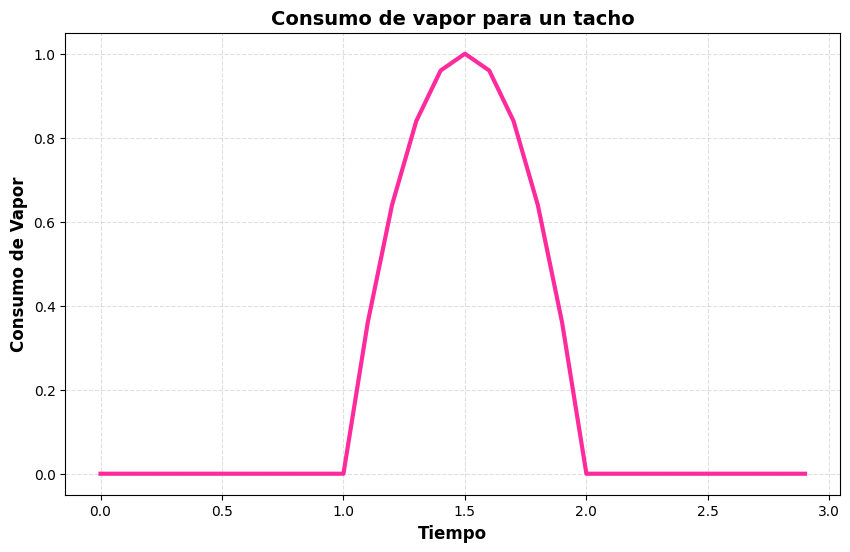

In [ ]:
def VaporTacho_i(t, t0):
  return 1 - (2*t0-2*t + 1)**2 if t > t0 and t < t0+1 else 0

import matplotlib.pyplot as plt
t0 = 1
intervalo = [x/10 for x in range(30)]
vt = [VaporTacho_i(t,t0) for t in intervalo]
plt.figure(figsize=(10, 6))
plt.plot(intervalo, vt, color='#FF1493', linewidth=3, alpha=0.9);
plt.xlabel('Tiempo', fontsize=12, fontweight='bold')
plt.ylabel('Consumo de Vapor', fontsize=12, fontweight='bold')
plt.title('Consumo de vapor para un tacho', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4, linestyle='--')
print('Consumo de vapor para un tacho, tomando como ejemplo t0 = %f'%t0)

Ahora suponga que la fábrica cuenta con una cantidad de tachos de cocimiento **N** que puede variar entre 5 y 20. Los tachos arrancan de manera
independiente entre ellos, y el vapor total puede ser calculado en cada instante de tiempo sumando el vapor producido por cada tacho. Es decir:

* VaporTotal(t) = SUM_i { VaporTacho_i(t) }

Consumo de vapor total con dos tachos, tomando como ejemplo t0 = 0.800000 y t0=1.100000


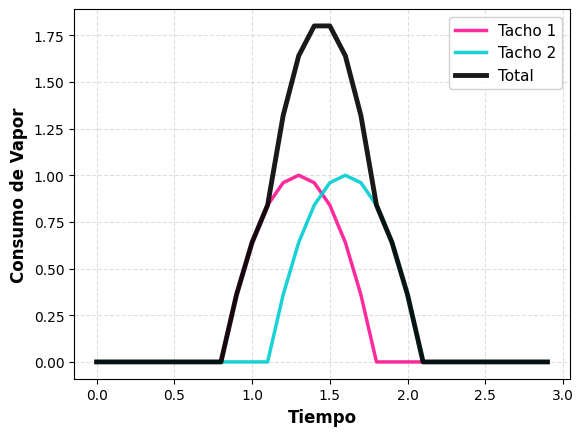

In [ ]:
def VaporTotal(t_inicios, intervalo):
  return [sum([VaporTacho_i(t,t0) for t0 in t_inicios]) for t in intervalo]

t0_1 = 0.8
t0_2 = 1.1
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
plt.plot(intervalo, vt1, label='Tacho 1', color='#FF1493', linewidth=2.5, alpha=0.9);
plt.plot(intervalo, vt2, label='Tacho 2', color='#00CED1', linewidth=2.5, alpha=0.9);
vtotal = VaporTotal([t0_1, t0_2], intervalo)
plt.plot(intervalo, vtotal, label='Total', color='#000000', linewidth=3.5, alpha=0.9);
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.4, linestyle='--')
plt.xlabel('Tiempo', fontsize=12, fontweight='bold')
plt.ylabel('Consumo de Vapor', fontsize=12, fontweight='bold')
print('Consumo de vapor total con dos tachos, tomando como ejemplo t0 = %f y t0=%f'%(t0_1,t0_2))

El objetivo del problema es diseñar un Algoritmo Genético que organice el cronograma de arranques (*Schedule*) de los tachos, de manera que:
* Todos los tachos deben completar su ciclo.
* Se estabilizce el consumo de vapor total (que no existan grandes variaciones de vapor durante todo el proceso). Es decir, se prefieren soluciones que produzcan un consumo de vapor "*constante*".
* Se prefieren soluciones que brinden un tiempo total de funcionamiento menor.
* Se debe evitar la convergencia hacia las soluciones triviales e incorrectas:
* El algoritmo debe ser general, funcionando para diferente cantidad de tachos **N**.
  * Donde el tiempo total es mínimo debido a que todos los tachos arrancan juntos.
  * Los tachos arrancan uno despues de otro (no se superponen).



Soluciones triviales a evitar:


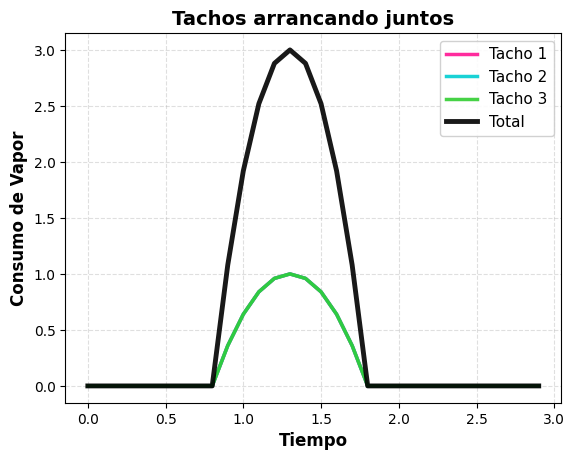

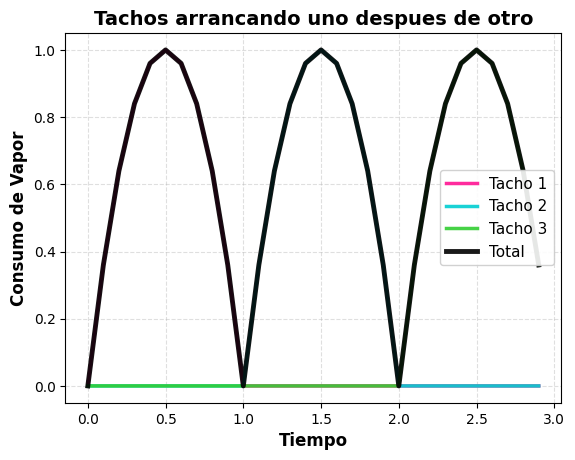

In [ ]:
t0_1 = 0.8
t0_2 = 0.8
t0_3 = 0.8
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
vt3 = [VaporTacho_i(t, t0_3) for t in intervalo]
vtotal = VaporTotal([t0_1, t0_2, t0_3], intervalo)
plt.plot(intervalo, vt1, label='Tacho 1', color='#FF1493', linewidth=2.5, alpha=0.9);
plt.plot(intervalo, vt2, label='Tacho 2', color='#00CED1', linewidth=2.5, alpha=0.9);
plt.plot(intervalo, vt3, label='Tacho 3', color='#32CD32', linewidth=2.5, alpha=0.9);
plt.plot(intervalo, vtotal, label='Total', color='#000000', linewidth=3.5, alpha=0.9);
plt.legend(fontsize=11, framealpha=0.9)
plt.title('Tachos arrancando juntos', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4, linestyle='--')
plt.xlabel('Tiempo', fontsize=12, fontweight='bold')
plt.ylabel('Consumo de Vapor', fontsize=12, fontweight='bold')

t0_1 = 0
t0_2 = 1
t0_3 = 2
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
vt3 = [VaporTacho_i(t, t0_3) for t in intervalo]
vtotal = VaporTotal([t0_1, t0_2, t0_3], intervalo)
plt.figure()
plt.plot(intervalo, vt1, label='Tacho 1', color='#FF1493', linewidth=2.5, alpha=0.9);
plt.plot(intervalo, vt2, label='Tacho 2', color='#00CED1', linewidth=2.5, alpha=0.9);
plt.plot(intervalo, vt3, label='Tacho 3', color='#32CD32', linewidth=2.5, alpha=0.9);
plt.plot(intervalo, vtotal, label='Total', color='#000000', linewidth=3.5, alpha=0.9);
plt.legend(fontsize=11, framealpha=0.9)
plt.title('Tachos arrancando uno despues de otro', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4, linestyle='--')
plt.xlabel('Tiempo', fontsize=12, fontweight='bold')
plt.ylabel('Consumo de Vapor', fontsize=12, fontweight='bold')
print("Soluciones triviales a evitar:")

La función fitness, entonces, deberá tener en cuenta las variaciones de vapor total en el tiempo, y el tiempo total del ciclo.

In [ ]:
import numpy as np

def calcular_timespan(solucion):
    """
    Calcula el tiempo total del ciclo (timespan).
    Timespan = max(t0_i + 1) - min(t0_i)
    """
    if len(solucion) == 0:
        return 0
    t_inicios = solucion
    t_finales = [t0 + 1 for t0 in t_inicios]
    timespan = max(t_finales) - min(t_inicios)
    return timespan

def calcular_variabilidad_vapor(solucion, intervalo):
    """
    Calcula la variabilidad del consumo de vapor total usando la desviación estándar.

    ¿Por qué desviación estándar?
    - El enunciado dice: "consumiendo mayor energía mientras mayor sea esta variación"
    - La desviación estándar mide qué tan dispersos están los valores del consumo
    - Si el consumo es CONSTANTE → desviación BAJA → menor energía consumida → MEJOR
    - Si el consumo VARÍA mucho (picos y valles) → desviación ALTA → mayor energía → PEOR

    Ejemplo:
    - Consumo constante [5, 5, 5, 5, 5] → desviación ≈ 0 → ÓPTIMO
    - Consumo variable [1, 9, 2, 8, 3] → desviación alta → MALO
    """
    if len(solucion) == 0:
        return float('inf')

    # Calcular vapor total en cada instante
    vapor_total = VaporTotal(solucion, intervalo)

    # Calcular desviación estándar (variabilidad)
    if len(vapor_total) == 0:
        return float('inf')

    # Desviación estándar: mide la dispersión de los valores alrededor de la media
    desviacion = np.std(vapor_total)

    return desviacion

def detectar_solucion_trivial_juntos(solucion, umbral=0.1):
    """
    Detecta si todos los tachos arrancan juntos (solución trivial).
    Retorna True si la diferencia máxima entre t0 es menor al umbral.
    """
    if len(solucion) < 2:
        return False
    diferencia_max = max(solucion) - min(solucion)
    return diferencia_max < umbral

def detectar_solucion_trivial_secuencial(solucion, umbral=0.9):
    """
    Detecta si los tachos arrancan uno después de otro sin superponerse.
    Retorna True si la diferencia mínima entre t0 consecutivos es >= umbral.
    """
    if len(solucion) < 2:
        return False
    solucion_ordenada = sorted(solucion)
    diferencias = [solucion_ordenada[i+1] - solucion_ordenada[i] for i in range(len(solucion_ordenada)-1)]
    if len(diferencias) == 0:
        return False
    diferencia_minima = min(diferencias)
    return diferencia_minima >= umbral

def fitnessTachos(solucion, intervalo, peso_variabilidad=3.5, peso_timespan=1.5,
                  penalizacion_trivial=5):

    #Con una peso_variabilidad=3, peso_timespan=1.5, penalizacion_trivial=20.0 es un resultado decente
    """
    Función fitness para el problema de tachos.

    Objetivos:
    1. Minimizar variabilidad del vapor total (preferir consumo constante)
    2. Minimizar tiempo total del ciclo (timespan)
    3. Evitar soluciones triviales

    Parámetros:
    - solucion: lista de tiempos de arranque t0 para cada tacho
    - intervalo: lista de tiempos discretos para evaluar
    - peso_variabilidad: peso del objetivo de variabilidad 
    - peso_timespan: peso del objetivo de timespan 
    - penalizacion_trivial: penalización fuerte para soluciones triviales 

    Retorna: valor de fitness (mayor es mejor, por lo que se negativiza)
    """
    # Validación básica
    if len(solucion) == 0:
        return -float('inf')

    # 1. Calcular variabilidad del vapor total
    variabilidad = calcular_variabilidad_vapor(solucion, intervalo)

    # 2. Calcular tiempo total (timespan)
    timespan = calcular_timespan(solucion)

    # 3. Detectar y penalizar soluciones triviales
    penalizacion = 0.0
    if detectar_solucion_trivial_juntos(solucion):
        penalizacion += penalizacion_trivial
    if detectar_solucion_trivial_secuencial(solucion):
        penalizacion += penalizacion_trivial

    # 4. Calcular fitness
    # Se negativiza porque queremos minimizar, pero el AG maximiza
    fitness = -(variabilidad * peso_variabilidad + timespan * peso_timespan + penalizacion)

    return fitness

# Prueba de la función fitness
solucion_prueba = [0, 0.3, 1, 0.5, 0.2]
variabilidad = calcular_variabilidad_vapor(solucion_prueba, intervalo)
timespan = calcular_timespan(solucion_prueba)
fitness = fitnessTachos(solucion_prueba, intervalo)

print(f"Variabilidad del vapor total: {variabilidad:.4f}")
print(f"Timespan (tiempo total): {timespan:.4f}")
print(f"Fitness: {fitness:.4f}")
print(f"¿Solución trivial (juntos)? {detectar_solucion_trivial_juntos(solucion_prueba)}")
print(f"¿Solución trivial (secuencial)? {detectar_solucion_trivial_secuencial(solucion_prueba)}")

Variabilidad del vapor total: 1.1665
Timespan (tiempo total): 2.0000
Fitness: -7.0829
¿Solución trivial (juntos)? False
¿Solución trivial (secuencial)? False



Se pide:
1. Determinar una codificación adecuada (forma de representar las soluciones  para el problema).
2. Definir las restricciones para los valores en la solución (determinar la matriz de *Bounds*).
3. En base a la codificación elegida, definir una función *Fitness* que permita encontrar buenas soluciones en base a los objetivos del problema.
4. Determinar una arquitectura de algoritmos genéticos adecuada para resolver el problema:
  * Definir que tipo de algoritmo genético utilizar.
  * Elegir los operadores genéticos a utilizar.
5. Ajustar los parámetros adecuadamentes usando los criterios utilizados en los prácticos anteriores. La cantidad de generaciones y tamaño de la población pueden variar al tomar diferentes cantidad de tachos presentes.

Operadores de Seleccion

Operadores de Cruzamiento

In [ ]:
# Operadores

def SUS(F, cant_selectos, eps):
    """ Operador de selección por torneos.
    Parametros:
    F: list. Lista de valores de fitness de cada individuo de la población.
    cant_selectos: int. Cantidad de individuos a seleccionar.
    eps: int. valor para normalizar el fitness.
    S: list. Lista con las posiciones de los individuos seleccionados.
    """

    ### HALLAMOS EL VALOR MINIMO DE LA LISTA F
    m= min(F)

    ### CALCULAMOS LOS AJUESTE DE FITTNES
    fitnessAjustada = [valor  - m  + eps for valor in F]

    ### SUMAMMOS TODOS LOS VALORES DE FITNES AJUATDA PARA HALLAR T
    T =  sum(fitnessAjustada)

    ### CALCULAMOS LOS PESOS ASOCIADAS A CADA INDIVIDUO
    Pesos = [x / T for x in fitnessAjustada]

    ###CONSTRUCCION DE LA RULETA
    C= list(accumulate(Pesos))  # aqui creamos los Ci usanado la funcion acummlate de intertools
    intervalos = []
    #AGEGAMOS EL PRIMERO INTERVALOS
    intervalos.insert(0,(0,C[0]))
    ##AGEGAMOS EL RESTO INTERVALOS
    for i in range(len(C)-1):

        intervalos.append((C[len(C)-(len(C)-i)],C[len(C)-(len(C)-i-1)]))

    segmentos=[0]
    for i in range(cant_selectos-1):
      segmentos.append((i+1)/cant_selectos)

    probabilidad=random.uniform(0,1/cant_selectos)

    ps = [  (x+probabilidad) for x in segmentos]

    selectos=[]


    for value in ps:
        selectos.append(find_interval(value, intervalos))

    return selectos

In [ ]:
# Operadores de Cruzamiento para Variables Continuas

def xov_arithmetic(p1, p2, alpha=0.5):
    """
    Operador de cruce aritmético para variables continuas.
    C1 = alpha * P1 + (1-alpha) * P2
    C2 = (1-alpha) * P1 + alpha * P2
    """
    c1 = [alpha * p1[i] + (1 - alpha) * p2[i] for i in range(len(p1))]
    c2 = [(1 - alpha) * p1[i] + alpha * p2[i] for i in range(len(p1))]
    return c1, c2

def xov_blend(p1, p2, alpha=0.03):
    """
    Operador BLX-alpha (Blend Crossover) para variables continuas.
    Genera hijos en el intervalo extendido [min - alpha*d, max + alpha*d]
    donde d = max - min entre los padres.
    """
    c1 = []
    c2 = []
    for i in range(len(p1)):
        x_min = min(p1[i], p2[i])
        x_max = max(p1[i], p2[i])
        d = x_max - x_min
        lower = x_min - alpha * d
        upper = x_max + alpha * d
        c1.append(random.uniform(lower, upper))
        c2.append(random.uniform(lower, upper))
    return c1, c2

def xov_uniform_continuo(p1, p2):
    """
    Operador de cruce uniforme para variables continuas.
    Similar al uniforme original pero sin restricciones de extremos fijos.
    """
    size = min(len(p1), len(p2))
    c1 = [0] * size
    c2 = [0] * size
    mascara = [random.randint(0, 1) for _ in range(size)]

    for i in range(size):
        if mascara[i] == 1:
            c1[i] = p1[i]
            c2[i] = p2[i]
        else:
            c1[i] = p2[i]
            c2[i] = p1[i]

    return c1, c2

def xov_single_point_continuo(p1, p2):
    """
    Operador de cruce de un punto para variables continuas.
    Sin restricciones de extremos fijos.
    """
    size = min(len(p1), len(p2))
    r = random.randint(1, size - 1)
    c1 = p1[:r] + p2[r:]
    c2 = p2[:r] + p1[r:]
    return c1, c2


In [ ]:
def xov_matriz(P1,P2):
  numeros_aleatorios = random.sample(range(len(P1)), len(P1))

  C1 = []
  C2 = []
  for i in range(len(numeros_aleatorios)):
    if i < len(numeros_aleatorios)/2:
      G1C1 = P1[numeros_aleatorios[i]]
      G2C1 = P2[numeros_aleatorios[i]]
      C1.append(G1C1)
      C1.append(G2C1)

    else:
      G1C2 = P1[numeros_aleatorios[i]]
      G2C2 = P2[numeros_aleatorios[i]]
      C2.append(G1C2)
      C2.append(G2C2)

  return C1,C2

def xov_partial_map(p1, p2):
    c1 = p1.copy()
    c2 = p2.copy()
    n = len(c1)
    #genero permutacion al azar para elegir dos puntos de corte distintos
    # Modificado para operar solo en las ciudades intermedias
    r = list(range(1, n - 1)) # Operar en indices 1 a n-2 (ciudades intermedias)
    random.shuffle(r)
    #creo la mascara, ahora de tamaño n-2 para las ciudades intermedias
    mask = [0]*(n-2)
    cut_start = min(r[:2]) - 1 # Ajustar indices para la mascara
    cut_end = max(r[:2]) - 1 # Ajustar indices para la mascara
    for i in range(cut_start, cut_end):
        mask[i] = 1

    #tacho valores que estan en p1 y p2, solo para las ciudades intermedias
    m1 = [1]*(n-2)
    m2 = [1]*(n-2)
    p1_intermediate = p1[1:-1] # Ciudades intermedias de P1
    p2_intermediate = p2[1:-1] # Ciudades intermedias de P2

    for i in range(n-2):
        if not mask[i]:
            for j in range(n-2):
                if p1_intermediate[i] == p2_intermediate[j]:
                    m1[j] = 0
                if p2_intermediate[i] == p1_intermediate[j]:
                    m2[j] = 0

    j = k = 0
    #pongo calores no tachados en c1 y c2, solo para las ciudades intermedias
    c1_intermediate = c1[1:-1]
    c2_intermediate = c2[1:-1]

    for i in range(n-2):
        if mask[i]:
            while j < (n-2) and m1[j] == 0:
                j += 1
            while k < (n-2) and m2[k] == 0:
                k += 1
            if j < (n-2):
                c1_intermediate[i] = p2_intermediate[j]
                j += 1
            if k < (n-2):
                c2_intermediate[i] = p1_intermediate[k]
                k += 1

    # Reconstruir los hijos con las ciudades fijas en los extremos
    c1 = [p1[0]] + c1_intermediate + [p1[-1]]
    c2 = [p2[0]] + c2_intermediate + [p2[-1]]


    return c1, c2

def xov_order_based(p1, p2):
    c1 = p1.copy()
    c2 = p2.copy()
    n = len(c1)
    #crear mascara al azar, solo para las ciudades intermedias
    mask = [random.randint(0,1) for i in range(n-2)]
    #tacho valores que estan en p1 y p2, solo para las ciudades intermedias
    m1 = [1]*(n-2)
    m2 = [1]*(n-2)
    p1_intermediate = p1[1:-1]
    p2_intermediate = p2[1:-1]

    for i in range(n-2):
        if not mask[i]:
            for j in range(n-2):
                if p1_intermediate[i] == p2_intermediate[j]:
                    m1[j] = 0
                if p2_intermediate[i] == p1_intermediate[j]:
                    m2[j] = 0
    j = k = 0
    #pongo calores no tachados en c1 y c2, solo para las ciudades intermedias
    c1_intermediate = c1[1:-1]
    c2_intermediate = c2[1:-1]

    for i in range(n-2):
        if mask[i]:
            while j < (n-2) and m1[j] == 0:
                j += 1
            while k < (n-2) and m2[k] == 0:
                k += 1
            if j < (n-2):
                c1_intermediate[i] = p2_intermediate[j]
                j += 1
            if k < (n-2):
                c2_intermediate[i] = p1_intermediate[k]
                k += 1

    # Reconstruir los hijos con las ciudades fijas en los extremos
    c1 = [p1[0]] + c1_intermediate + [p1[-1]]
    c2 = [p2[0]] + c2_intermediate + [p2[-1]]

    return c1, c2

def xov_uniform(P1, P2):
    """Operador Uniform Crossover para Algoritmos Geneticos.
    Parametros:
    P1: list. Lista correspondiente a uno de los individuos padres a cruzar.
    P2: list. Lista correspondiente a uno de los individuos padres a cruzar.
    Modificado para mantener fijos los extremos.
    """
    size = min(len(P1), len(P2))
    c1 = [0] * size
    c2 = [0] * size

    # Mantener fijos los extremos
    c1[0] = P1[0]
    c1[-1] = P1[-1]
    c2[0] = P2[0]
    c2[-1] = P2[-1]

    # Operar solo en las ciudades intermedias
    intermediate_size = size - 2
    mascara = [random.randint(0, 1) for _ in range(intermediate_size)]

    p1_intermediate = P1[1:-1]
    p2_intermediate = P2[1:-1]
    c1_intermediate = [0] * intermediate_size
    c2_intermediate = [0] * intermediate_size

    for i in range(intermediate_size):
        if mascara[i] == 1:
            c1_intermediate[i] = p1_intermediate[i]
            c2_intermediate[i] = p2_intermediate[i]
        else:
            c1_intermediate[i] = p2_intermediate[i]
            c2_intermediate[i] = p1_intermediate[i]

    # Reconstruir los hijos
    c1 = [c1[0]] + c1_intermediate + [c1[-1]]
    c2 = [c2[0]] + c2_intermediate + [c2[-1]]

    return c1, c2

def xov_single_point(P1, P2):
    """Operador Single Point Crossover para Algoritmos Geneticos.
    Parametros:
    P1: list. Lista correspondiente a uno de los individuos padres a cruzar.
    P2: list. Lista correspondiente a uno de los individuos padres a cruzar.
    Modificado para mantener fijos los extremos.
    """
    size = min(len(P1), len(P2))
    # Elegir punto de corte solo en las ciudades intermedias
    r = random.randint(1, size - 2) # Punto de corte despues del primer elemento y antes del ultimo

    # Mantener fijos los extremos y cruzar la parte intermedia
    c1 = P1[:r+1] + P2[r+1:]
    c2 = P2[:r+1] + P1[r+1:]

    # Asegurar que los extremos sigan siendo los originales (aunque el slicing ya deberia hacerlo si r es entre 1 y size-2)
    c1[0] = P1[0]
    c1[-1] = P1[-1]
    c2[0] = P2[0]
    c2[-1] = P2[-1]


    return c1, c2

def xov_single_point_shuffle(P1,P2):
  # Este operador es mas complejo de adaptar para mantener fijos los extremos
  # Dejaremos la version original por ahora, ya que los operadores de permutacion
  # como PMX, OX, etc. son mas adecuados para TSP con restricciones.
  # Si se requiere adaptar este, se necesitaria asegurar que la permutacion y la inversa
  # manejen correctamente los elementos fijos.
  permutacion = random.sample(range(len(P1)), len(P1))

  C1 = [0] * len(permutacion)
  C2 = [0] * len(permutacion)
  p1 = [0]*len(permutacion)
  p2 = [0]*len(permutacion)
  for i in range(len(permutacion)):
    p1[permutacion[i]] = P1[i]
    p2[permutacion[i]] = P2[i]

  r = random.randint(1, len(P1)-1)

  c1 = p1[:r+1] + p2[r+1:]
  c2 = p2[:r+1] + p1[r+1:]

  inversa = [0] * len(permutacion)

  for i, valor in enumerate(permutacion):
    inversa[valor] = i

  for i in range(len(permutacion)):
    C1[inversa[i]] = c1[i]
    C2[inversa[i]] = c2[i]

  return C1 ,C2

In [ ]:
# Operadores de Mutación para Variables Continuas

def mut_gaussian(p, Bounds, sigma=0.1):
    """
    Mutación gaussiana para variables continuas.
    Añade ruido gaussiano a cada variable con probabilidad uniforme.
    """
    m = p.copy()
    for i in range(len(m)):
        if random.random() < 0.5:  # Probabilidad de mutar cada variable
            # Añadir ruido gaussiano
            nuevo_valor = m[i] + random.gauss(0, sigma)
            # Asegurar que esté dentro de los bounds
            m[i] = max(Bounds[i][0], min(Bounds[i][1], nuevo_valor))
    return m

def mut_uniform(p, Bounds):
    """
    Mutación uniforme para variables continuas.
    Reemplaza una variable aleatoria con un valor aleatorio dentro de sus bounds.
    """
    m = p.copy()
    idx = random.randint(0, len(m) - 1)
    m[idx] = random.uniform(Bounds[idx][0], Bounds[idx][1])
    return m

def mut_polynomial(p, Bounds, eta=20):
    """
    Mutación polinomial (usada en NSGA-II) para variables continuas.
    Genera variaciones más suaves que la mutación uniforme.
    """
    m = p.copy()
    for i in range(len(m)):
        if random.random() < 0.1:  # Probabilidad de mutar cada variable
            u = random.random()
            delta = 0.0
            if u < 0.5:
                delta_l = (2 * u) ** (1 / (eta + 1)) - 1
                delta = delta_l
            else:
                delta_r = 1 - (2 * (1 - u)) ** (1 / (eta + 1))
                delta = delta_r

            # Aplicar la variación
            rango = Bounds[i][1] - Bounds[i][0]
            nuevo_valor = m[i] + delta * rango
            m[i] = max(Bounds[i][0], min(Bounds[i][1], nuevo_valor))
    return m

def mut_boundary_continuo(p, Bounds):
    """
    Mutación boundary para variables continuas.
    Establece una variable aleatoria a uno de sus límites.
    """
    m = p.copy()
    idx = random.randint(0, len(m) - 1)
    m[idx] = random.choice([Bounds[idx][0], Bounds[idx][1]])
    return m


Operadores de Mutacion

In [ ]:
# Operadores adicionales

def mut_swap(p, Bounds, n=1):
    m = p.copy()
    #genero permutacion al azar para elegir coordenadas distintas al azar
    # Modificado para operar solo en las ciudades intermedias
    r = list(range(1, len(m)-1))  # Operar en indices 1 a len(m)-2
    if len(r) < 2*n: # Asegurar que hay suficientes elementos para intercambiar
        print(f"Advertencia: No hay suficientes elementos intermedios para mutación swap con n={n}. Se omitirá la mutación.")
        return m # Retorna el individuo sin mutar

    random.shuffle(r)
    #indices de coordenadas origen (en el rango intermedio)
    o = r[:n]
    #indices de coordenadas destino (en el rango intermedio)
    d = r[n:2*n]
    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
        m[d[i]] = p[o[i]]
    return m

def mut_adjoin_swap(p, Bounds, n=1):
    #copio el padre
    m = p.copy()
    #genero permutacion al azar para elegir coordenadas distintas al azar
    # Modificado para operar solo en las ciudades intermedias
    r = list(range(1, len(m)-2))  # Operar en indices 1 a len(m)-3 para asegurar que el adyacente tambien este en el rango intermedio
    if len(r) < n:
         print(f"Advertencia: No hay suficientes elementos intermedios para mutación adjoin_swap con n={n}. Se omitirá la mutación.")
         return m # Retorna el individuo sin mutar

    random.shuffle(r)
    #indices de coordenadas origen (en el rango intermedio)
    o = r[:n]
    #indices de coordenadas destino (adyacentes a origen, en el rango intermedio)
    d = [(x + 1) for x in o]

    # Asegurar que todos los indices destino esten dentro del rango intermedio
    if any(idx >= len(m)-1 for idx in d):
         print(f"Advertencia: Los indices adyacentes se salen del rango intermedio para mutación adjoin_swap. Se omitirá la mutación.")
         return m # Retorna el individuo sin mutar


    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
        m[d[i]] = p[o[i]]
    return m

def mut_inversion(p, Bounds):
    #copio el padre
    m = p.copy()
    n = len(m)
    #genero permutacion al azar para elegir dos puntos de corte distintos
    # Modificado para operar solo en las ciudades intermedias
    r = list(range(1, n - 1)) # Operar en indices 1 a n-2
    if len(r) < 2:
         print(f"Advertencia: No hay suficientes elementos intermedios para mutación inversion. Se omitirá la mutación.")
         return m # Retorna el individuo sin mutar

    random.shuffle(r)
    #indices de corte ajustados para el rango intermedio
    cut1 = min(r[:2])
    cut2 = max(r[:2])

    # Invertir solo la sublista de ciudades intermedias entre cut1 y cut2
    m[cut1:cut2+1] = m[cut1:cut2+1][::-1]

    return m

def mut_shift_left(p, Bounds):
    #copio el padre
    m = p.copy()
    n = len(m)
    #genero permutacion al azar para elegir dos puntos de corte distintos
    # Modificado para operar solo en las ciudades intermedias
    r = list(range(1, n - 1)) # Operar en indices 1 a n-2
    if len(r) < 2:
         print(f"Advertencia: No hay suficientes elementos intermedios para mutación shift_left. Se omitirá la mutación.")
         return m # Retorna el individuo sin mutar

    random.shuffle(r)
    #indices de corte ajustados para el rango intermedio
    cut1 = min(r[:2])
    cut2 = max(r[:2])

    # Extraer la sublista intermedia
    sublist = m[cut1:cut2+1]
    # Realizar shift left en la sublista
    shifted_sublist = sublist[1:] + [sublist[0]]
    # Reemplazar la sublista en el individuo
    m[cut1:cut2+1] = shifted_sublist

    return m

def mut_shift_right(p, Bounds):
    #copio el padre
    m = p.copy()
    n = len(m)
    #genero permutacion al azar para elegir dos puntos de corte distintos
    # Modificado para operar solo en las ciudades intermedias
    r = list(range(1, n - 1)) # Operar en indices 1 a n-2
    if len(r) < 2:
         print(f"Advertencia: No hay suficientes elementos intermedios para mutación shift_right. Se omitirá la mutación.")
         return m # Retorna el individuo sin mutar

    random.shuffle(r)
    #indices de corte ajustados para el rango intermedio
    cut1 = min(r[:2])
    cut2 = max(r[:2])

    # Extraer la sublista intermedia
    sublist = m[cut1:cut2+1]
    # Realizar shift right en la sublista
    shifted_sublist = [sublist[-1]] + sublist[:-1]
    # Reemplazar la sublista en el individuo
    m[cut1:cut2+1] = shifted_sublist

    return m


def mut_boundary(P, Bounds):
    """Step Mutation
    Parámetros
    P: list. Vector correspondiente a un individuo.
    bounds: list. Matriz que indica los valores maximo y minimo de cada coordenada.
    Modificado para operar solo en las ciudades intermedias.
    """
    C = P.copy()
    n = len(C)
    # Elegir un punto de mutacion solo en las ciudades intermedias
    cut = random.randint(1, n-2)
    # Mutar el valor dentro de los limites de esa posicion (aunque para TSP esto no tiene sentido si esperamos permutaciones)
    # Para TSP con permutaciones, una mutacion boundary no es un operador adecuado a menos que se redefina.
    # Si se quiere un cambio minimo, podriamos simplemente intercambiar con un vecino aleatorio en el rango intermedio.
    # Sin embargo, si Bounds tiene un significado para cada posicion (no es el caso del TSP), se aplicaria la mutacion boundary original.
    # Dado el contexto de TSP y permutaciones, este operador no es ideal.
    # Si insistimos en usarlo, debemos redefinir su comportamiento para permutaciones.
    # Una mutacion boundary minimal para permutaciones podria ser intercambiar el elemento elegido con un elemento aleatorio en el rango intermedio.
    # O simplemente deshabilitar este operador para TSP.
    # Por ahora, lo adaptaremos para operar solo en el rango intermedio, aunque su utilidad para TSP es cuestionable.
    # C[cut] = random.randint(Bounds[cut][0], Bounds[cut][1]) # Comentado porque no es adecuado para TSP

    # Adaptacion minimal para TSP: intercambiar el elemento elegido con otro elemento aleatorio en el rango intermedio
    if n > 3: # Asegurar que hay al menos 3 ciudades (1, inter, 1) para tener un rango intermedio > 0
        idx_to_swap = random.randint(1, n-2) # Indice del elemento a intercambiar
        # Elegir otro indice aleatorio en el rango intermedio, diferente al primero
        other_idx = random.choice([i for i in range(1, n-1) if i != idx_to_swap])
        C[idx_to_swap], C[other_idx] = C[other_idx], C[idx_to_swap] # Realizar el swap
    else:
         print(f"Advertencia: No hay suficientes elementos intermedios para mutación boundary adaptada. Se omitirá la mutación.")


    return C
def find_interval(value, intervals): # FUNCION PARA VERIFICAR SI EL NUMERO ALEATORIO SE ENCUENTRA DENTRO DE LOS INTERVALOS DISPONIBLES
    for i, (start, end) in enumerate(intervals):

        if  start <= value <= end:
            return i

In [ ]:
import random
import math
from itertools import accumulate

def geneticoSimple_Tachos(Pop, cant_generac, Bounds, Enteras, sel, xover, mut,
                          cant_cruzados, cant_mutados, cant_elite, param_sel, f,
                          intervalo, mut2=None, porcentaje_mut1=1.0, porcentaje_mut2=0.0,
                          xover2=None, porcentaje_xover1=1.0, porcentaje_xover2=0.0,
                          callback=None):
    """
    Algoritmo Genético Simple adaptado para el Problema de Tachos.
    Parámetros:
    - Pop: list. Población inicial (lista de listas de tiempos t0).
    - cant_generac: int. Cantidad de iteraciones del algoritmo.
    - Bounds: list. Matriz que indica los valores max y min de cada variable.
    - Enteras: list. Vector booleano que indica si las coordenadas son enteras.
    - cant_cruzados: int. Cantidad de individuos que serán cruzados.
    - cant_mutados: int. Cantidad de soluciones a las cuales se aplicará mutación.
    - cant_elite: int. Número de mejores soluciones que pasan a la siguiente generación.
    - param_sel: float. Parámetro usado en la selección.
    - f: function. Función de evaluación (fitness). Debe recibir (solucion, intervalo).
    - intervalo: list. Lista de tiempos discretos para evaluar el vapor.
    - mut2: function (opcional). Segundo operador de mutación.
    - porcentaje_mut1: float. Porcentaje de uso del primer operador de mutación.
    - porcentaje_mut2: float. Porcentaje de uso del segundo operador de mutación.
    - xover2: function (opcional). Segundo operador de cruzamiento.
    - porcentaje_xover1: float. Porcentaje de uso del primer operador de cruzamiento.
    - porcentaje_xover2: float. Porcentaje de uso del segundo operador de cruzamiento.
    - callback: function. Función que se ejecuta en cada iteración.

    Salida:
    - soluc: list. Vector solución con mejor fitness.
    - solF: float. Valor de evaluación de la mejor solución.
    - Pop: list. Población final.
    - Fit: list. Fitness de cada individuo de la población final.
    - traceBest: list. Mejores valores de fitness por generación.
    - traceAvg: list. Valores promedio de fitness por generación.
    - bestSols: list. Mejores soluciones por generación.
    """
    #inicializacion
    sol = []
    solF = None
    cant_soluc = len(Pop)
    Fit = [None] * cant_soluc
    traceBest = []
    traceAvg = []
    bestSols = []
    best_fitness_overall = -math.inf
    generations_no_improve = 0
    max_no_improve = 40 # Condición de terminación


    #verifico los parametros de entrada
    cant_soluc = len(Pop)
    if cant_soluc < 2:
        print('La Poblacion debe tener al menos dos individuos.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

    # Calculate number of variables from Bounds, which is reliable
    cant_variables = len(Bounds)


    if len(Enteras) != cant_variables:
        print('El tamano del vector Enteras es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if len(Bounds) != cant_variables or len(Bounds[0]) != 2:
        print('El tamano de la matriz Bounds es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_cruzados > cant_soluc:
        print('La cantidad de cruzados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_mutados > cant_soluc:
        print('La cantidad de mutados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_elite >= cant_soluc:
        print('El tamano de la elite debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

    #inicializo variables para reducir tiempo de calculo
    cb_param = None
    p = [i for i in range(cant_soluc)]


    # Evaluaciones de la población inicial
    for k in range(cant_soluc):
        Fit[k] = f(Pop[k], intervalo)

    if callback != None:
        cb_param = callback(Pop, Fit, Bounds, 0, cant_generac, cb_param)
    #obtengo el orden de los individuos
    p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)
    current_gen_best_fitness = Fit[p_orden[0]]

    # Initialize best_fitness_overall and traceBest with the first generation's best
    best_fitness_overall = current_gen_best_fitness
    traceBest.append(best_fitness_overall)
    traceAvg.append(sum(Fit) / len(Fit))
    bestSols.append([xi for xi in Pop[p_orden[0]]])


    for gen in range(cant_generac):
        # Check for stopping condition
        if generations_no_improve >= max_no_improve:
            #print(f"Stopping early: No improvement in best fitness for {max_no_improve} generations.")
            break

        #selecciono la elite de la generacion actual (una copia)
        Elite = [[xi for xi in Pop[p_orden[k]]] for k in range(cant_elite)]
        Elite_Fit = [Fit[p_orden[k]] for k in range(cant_elite)]

        #seleccion
        #Fit.sort(reverse=True)
        p_sel = sel(Fit, cant_soluc, param_sel) # Assuming sel function is available
        random.shuffle(p)
        Pop = [Pop[p_sel[k]] for k in p]
        Fit = [Fit[p_sel[k]] for k in p]

        # Cruzamiento con soporte para dos operadores de cruzamiento con porcentajes
        random.shuffle(p)
        for k in range(0, cant_cruzados-1, 2):
            # Default: If not crossed, keep parents
            C1, C2 = Pop[p[k]], Pop[p[k+1]]

            # Seleccionar el operador de cruzamiento según los porcentajes
            if xover2 is not None:
                rand_val = random.random()
                if rand_val < porcentaje_xover1:
                    # Usar el primer operador de cruzamiento
                    C1, C2 = xover(Pop[p[k]], Pop[p[k+1]])
                elif rand_val < (porcentaje_xover1 + porcentaje_xover2):
                    # Usar el segundo operador de cruzamiento
                    C1, C2 = xover2(Pop[p[k]], Pop[p[k+1]])
                # else: C1, C2 remain parents, as set by default before the if-else block
            else:
                # Usar solo el primer operador de cruzamiento
                C1, C2 = xover(Pop[p[k]], Pop[p[k+1]])

            # Ensure children are within bounds and are integers if required
            C1 = [max(Bounds[i][0], min(Bounds[i][1], xi)) for i, xi in enumerate(C1)]
            C1 = [int(round(xi)) if Enteras[i] else xi for i, xi in enumerate(C1)]
            C2 = [max(Bounds[i][0], min(Bounds[i][1], xi)) for i, xi in enumerate(C2)]
            C2 = [int(round(xi)) if Enteras[i] else xi for i, xi in enumerate(C2)]

            Pop[p[k]] = [xi for xi in C1]
            Pop[p[k+1]] = [xi for xi in C2]
            Fit[p[k]] = None
            Fit[p[k+1]] = None

        #mutacion con soporte para dos operadores de mutación con porcentajes
        random.shuffle(p)
        for k in range(cant_mutados):
            # Seleccionar el operador de mutación según los porcentajes
            if mut2 is not None:
                # Usar dos operadores de mutación con porcentajes
                rand_val = random.random()
                if rand_val < porcentaje_mut1:
                    # Usar el primer operador de mutación
                    C = mut(Pop[p[k]], Bounds)
                else:
                    # Usar el segundo operador de mutación
                    C = mut2(Pop[p[k]], Bounds)
            else:
                # Usar solo el primer operador de mutación
                C = mut(Pop[p[k]], Bounds)

            # Ensure mutated individual is within bounds and is integer if required
            C = [max(Bounds[i][0], min(Bounds[i][1], xi)) for i, xi in enumerate(C)]
            C = [int(round(xi)) if Enteras[i] else xi for i, xi in enumerate(C)]
            Pop[p[k]] = [xi for xi in C]
            Fit[p[k]] = None

        #inserto la elite en la nueva poblacion en lugares al azar
        random.shuffle(p)
        for k in range(cant_elite):
            Pop[p[k]] = Elite[k]
            Fit[p[k]] = Elite_Fit[k]

        # Evaluaciones
        for k in range(cant_soluc):
            if Fit[k] == None:
                Pop[k] = [max(Bounds[i][0], min(Bounds[i][1], xi)) for i, xi in enumerate(Pop[k])]
                Pop[k] = [int(round(xi)) if Enteras[i] else xi for i, xi in enumerate(Pop[k])]
                Fit[k] = f(Pop[k], intervalo)

        #obtengo el orden de los individuos
        p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)

        #datos estadisticos
        current_gen_best_fitness = Fit[p_orden[0]]
        traceAvg.append(sum(Fit) / len(Fit))
        bestSols.append([xi for xi in Pop[p_orden[0]]])

        # Update best_fitness_overall and traceBest (cumulative best)
        if current_gen_best_fitness > best_fitness_overall:
            best_fitness_overall = current_gen_best_fitness
            generations_no_improve = 0
        else:
            generations_no_improve += 1
        traceBest.append(best_fitness_overall)


        #funcion para graficar, mostrar, etc.
        if callback != None:
            cb_param = callback(Pop, Fit, Bounds, gen, cant_generac, cb_param)

    # Mejor solución
    p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)
    solF = Fit[p_orden[0]]
    sol = Pop[p_orden[0]]

    return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

In [ ]:
import random
import math
from itertools import accumulate
import numpy as np
import matplotlib.pyplot as plt

# Configuración del problema de tachos
num_tachos = 10  # Número de tachos (puede variar entre 5 y 20)

# Nuevo parámetro para controlar la longitud del intervalo de evaluación
eval_interval_length = 5.0 # Duración total del intervalo de evaluación
intervalo = [x/10 for x in range(int(eval_interval_length * 10))]  # Intervalo de tiempo más amplio
limiteSuperior = max(intervalo) - 1  # Los tachos deben terminar antes del final del intervalo

# Función de inicialización de población
def init_pop_tachos(cant_individuos, num_tachos, Bounds):
    """Inicializa población con tiempos de arranque aleatorios para cada tacho."""
    poblacion = []
    for _ in range(cant_individuos):
        individuo = [random.uniform(Bounds[i][0], Bounds[i][1]) for i in range(num_tachos)]
        poblacion.append(individuo)
    return poblacion

# Configuración de Bounds
Bounds = [[0, limiteSuperior] for _ in range(num_tachos)]
Enteras = [False] * num_tachos  # Variables continuas

# Configuración del AG
cant_individuos = 20  # Tamaño de población
cant_generac =  1000# Generaciones
sel = SUS
eps = 0.5

cant_cruzados = round(0.7 * cant_individuos)
cant_mutados = round(0.2 * cant_individuos)
cant_elite = 1

# Operadores de cruzamiento
xover = xov_uniform_continuo  # Primer operador de cruce para variables continuas
xover2 = xov_blend  # Segundo operador de cruce (opcional)
porcentaje_xover1 = 0.95 # % de los cruzamientos usarán el primer operador (95%)
porcentaje_xover2 = 0.05 # % de los cruzamientos usarán el segundo operador (5%)


# Operadores de mutación
mut = mut_polynomial  # Primer operador de mutación
mut2 = mut_gaussian  # Segundo operador de mutación (opcional)
porcentaje_mut1 = 0.6  # % de las mutaciones usarán el primer operador
porcentaje_mut2 = 0.4  # % de las mutaciones usarán el segundo operador


callback = None

# Función para graficar evolución
def graficarEvolucionFitness1(best, mean, numero):
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes()
    x = range(len(best))
    # Colores vibrantes y llamativos
    plt.plot(x, best, label='Mejor solución', color='#0066CC', linewidth=2.5, alpha=0.9)
    plt.plot(x, mean, label='Promedio población', color='#FF6600', linewidth=2.5, linestyle='--', alpha=0.9)
    plt.title(f'Valores de Evaluación de la Ejecución {numero + 1}', fontsize=14, fontweight='bold')
    plt.xlabel('Generación', fontsize=12, fontweight='bold')
    plt.ylabel('Fitness', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.4, linestyle='--')
    plt.legend(fontsize=11, framealpha=0.9)


  EJECUTANDO PARA 5 TACHOS

  Ejecución 1/10 para 5 tachos...

  Ejecución 2/10 para 5 tachos...

  Ejecución 3/10 para 5 tachos...

  Ejecución 4/10 para 5 tachos...

  Ejecución 5/10 para 5 tachos...

  Ejecución 6/10 para 5 tachos...

  Ejecución 7/10 para 5 tachos...

  Ejecución 8/10 para 5 tachos...

  Ejecución 9/10 para 5 tachos...

  Ejecución 10/10 para 5 tachos...

✅ Completadas 10 ejecuciones para 5 tachos

  EJECUTANDO PARA 10 TACHOS

  Ejecución 1/10 para 10 tachos...

  Ejecución 2/10 para 10 tachos...

  Ejecución 3/10 para 10 tachos...

  Ejecución 4/10 para 10 tachos...

  Ejecución 5/10 para 10 tachos...

  Ejecución 6/10 para 10 tachos...

  Ejecución 7/10 para 10 tachos...

  Ejecución 8/10 para 10 tachos...

  Ejecución 9/10 para 10 tachos...

  Ejecución 10/10 para 10 tachos...

✅ Completadas 10 ejecuciones para 10 tachos

  EJECUTANDO PARA 15 TACHOS

  Ejecución 1/10 para 15 tachos...

  Ejecución 2/10 para 15 tachos...

  Ejecución 3/10 para 15 tachos...

  Ej

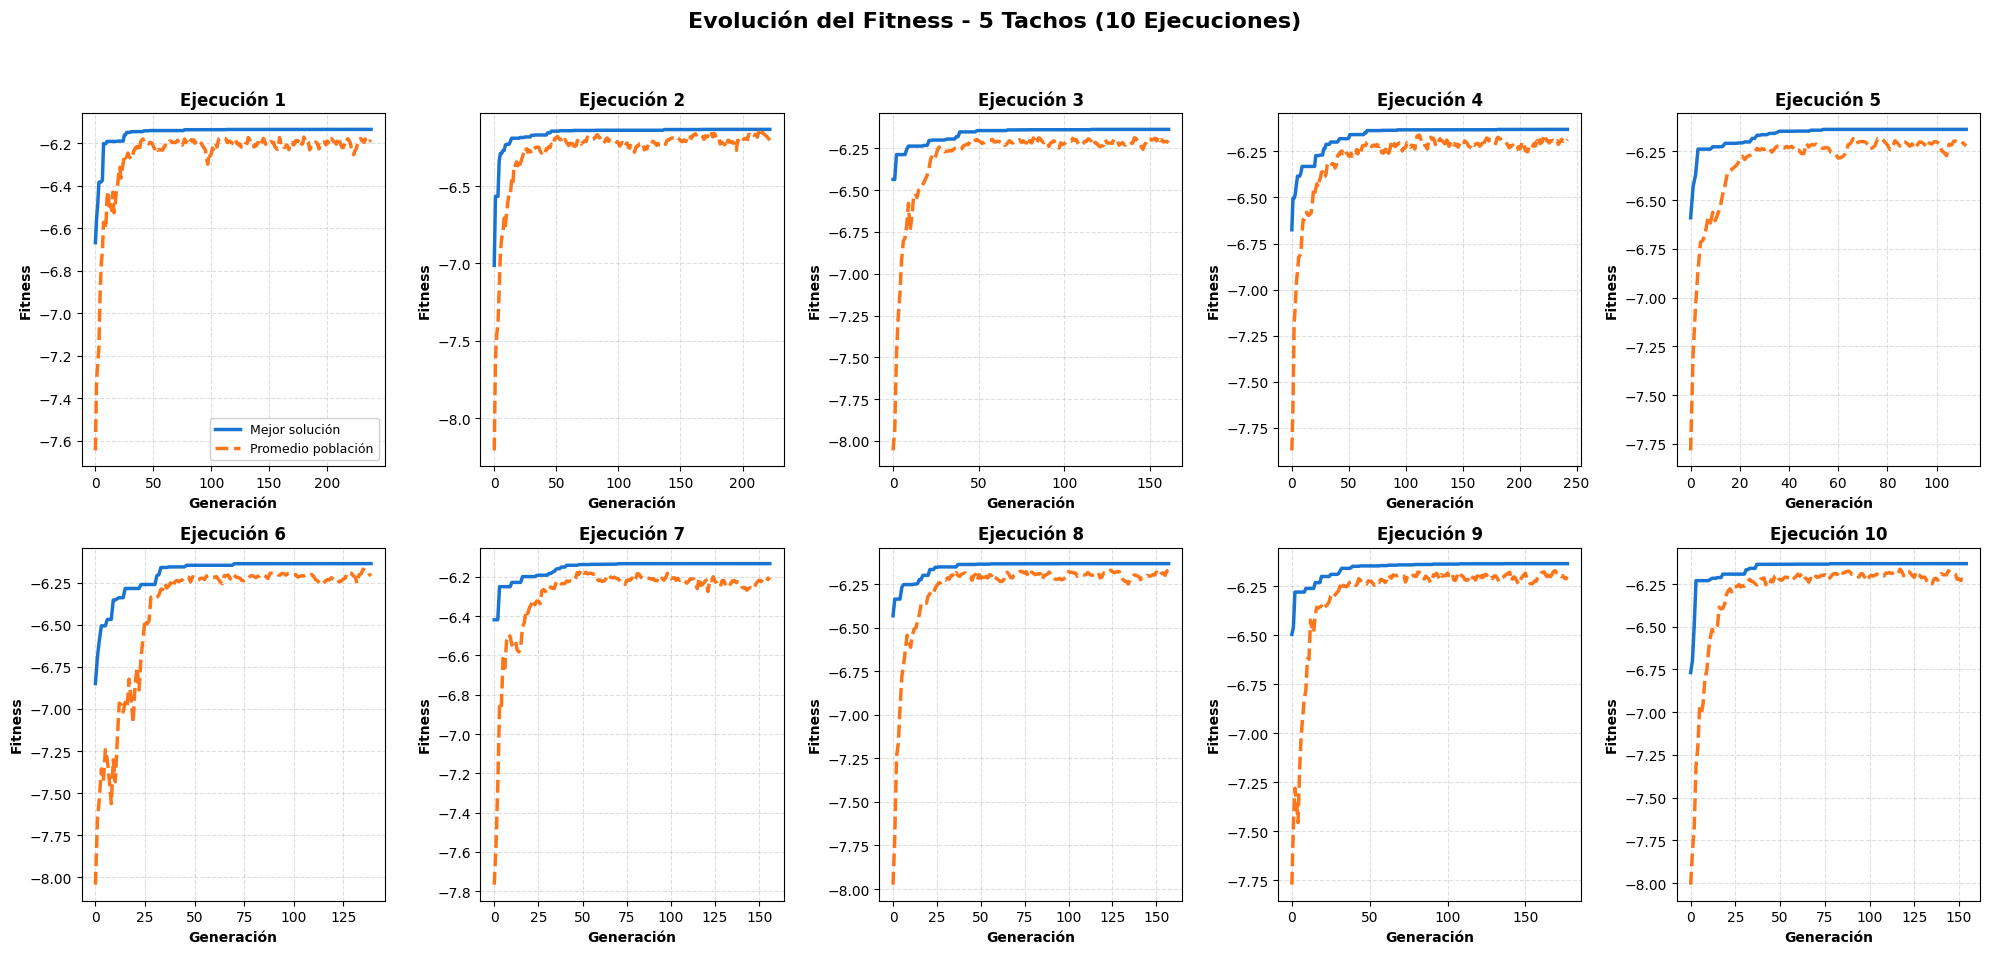

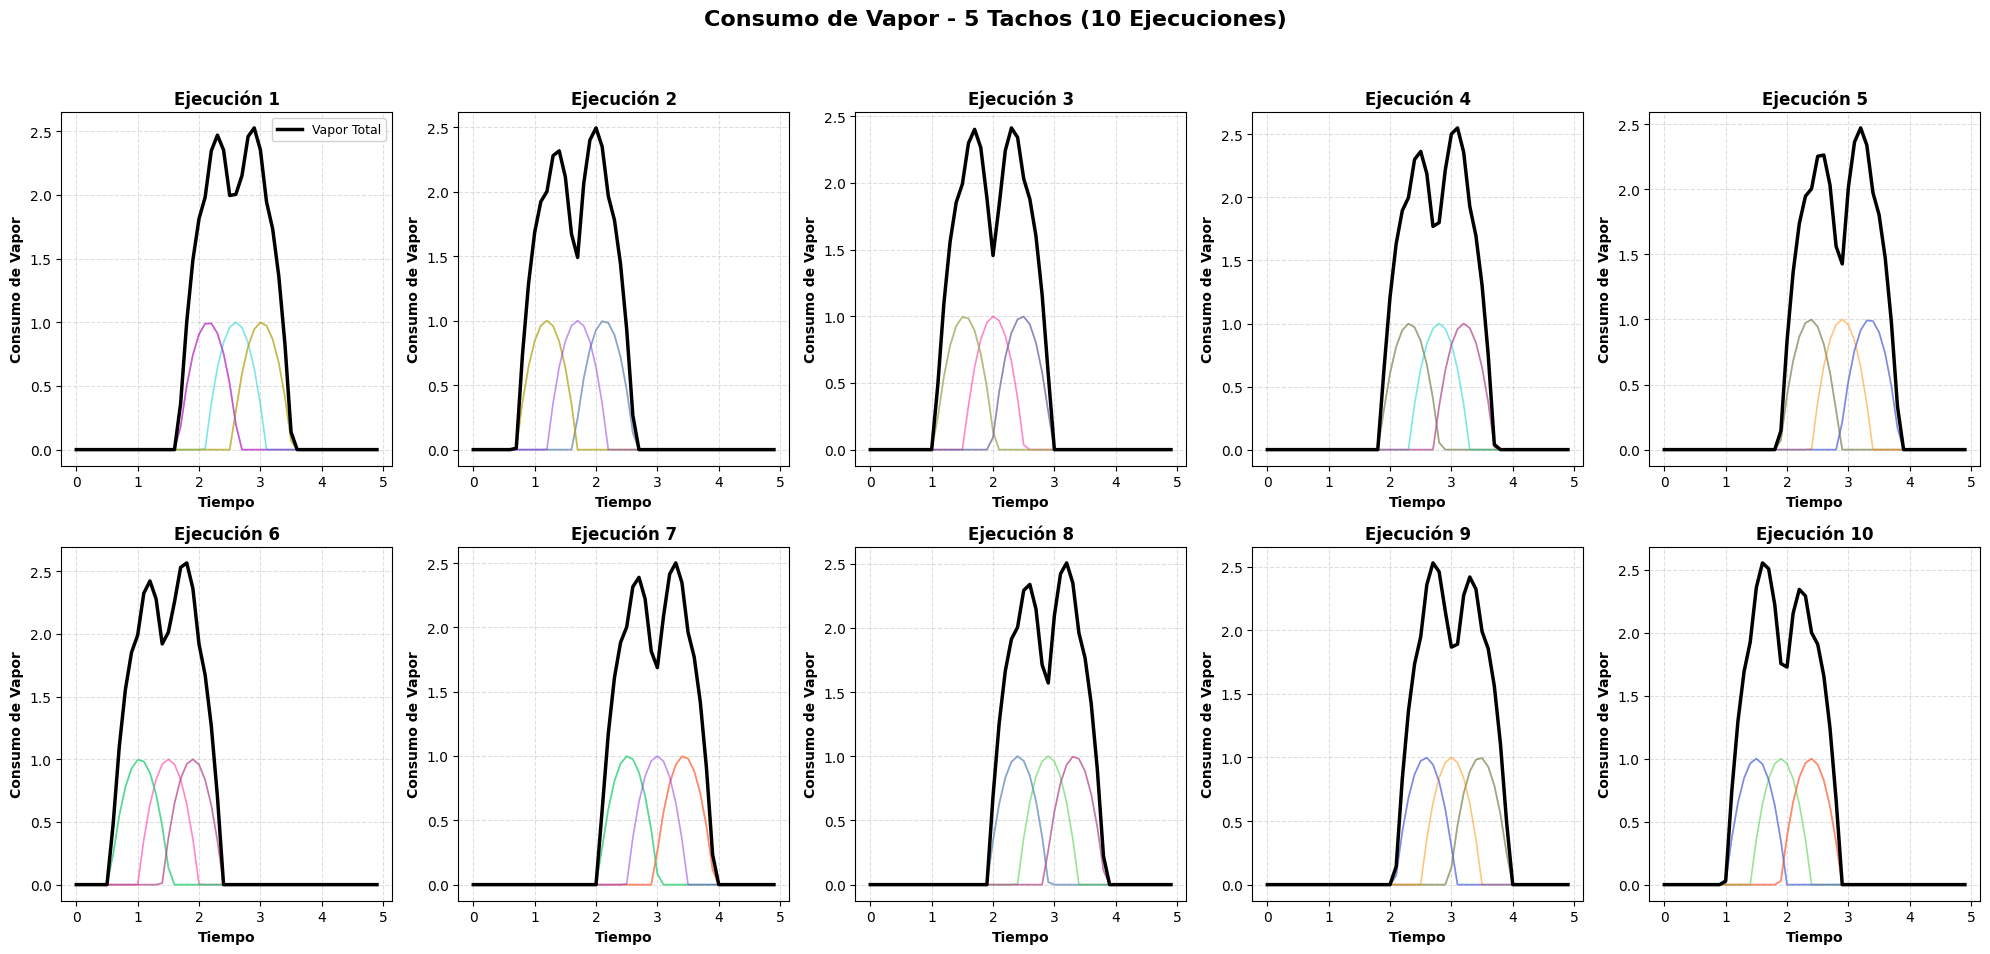


📊 Generando gráficos para 10 tachos...


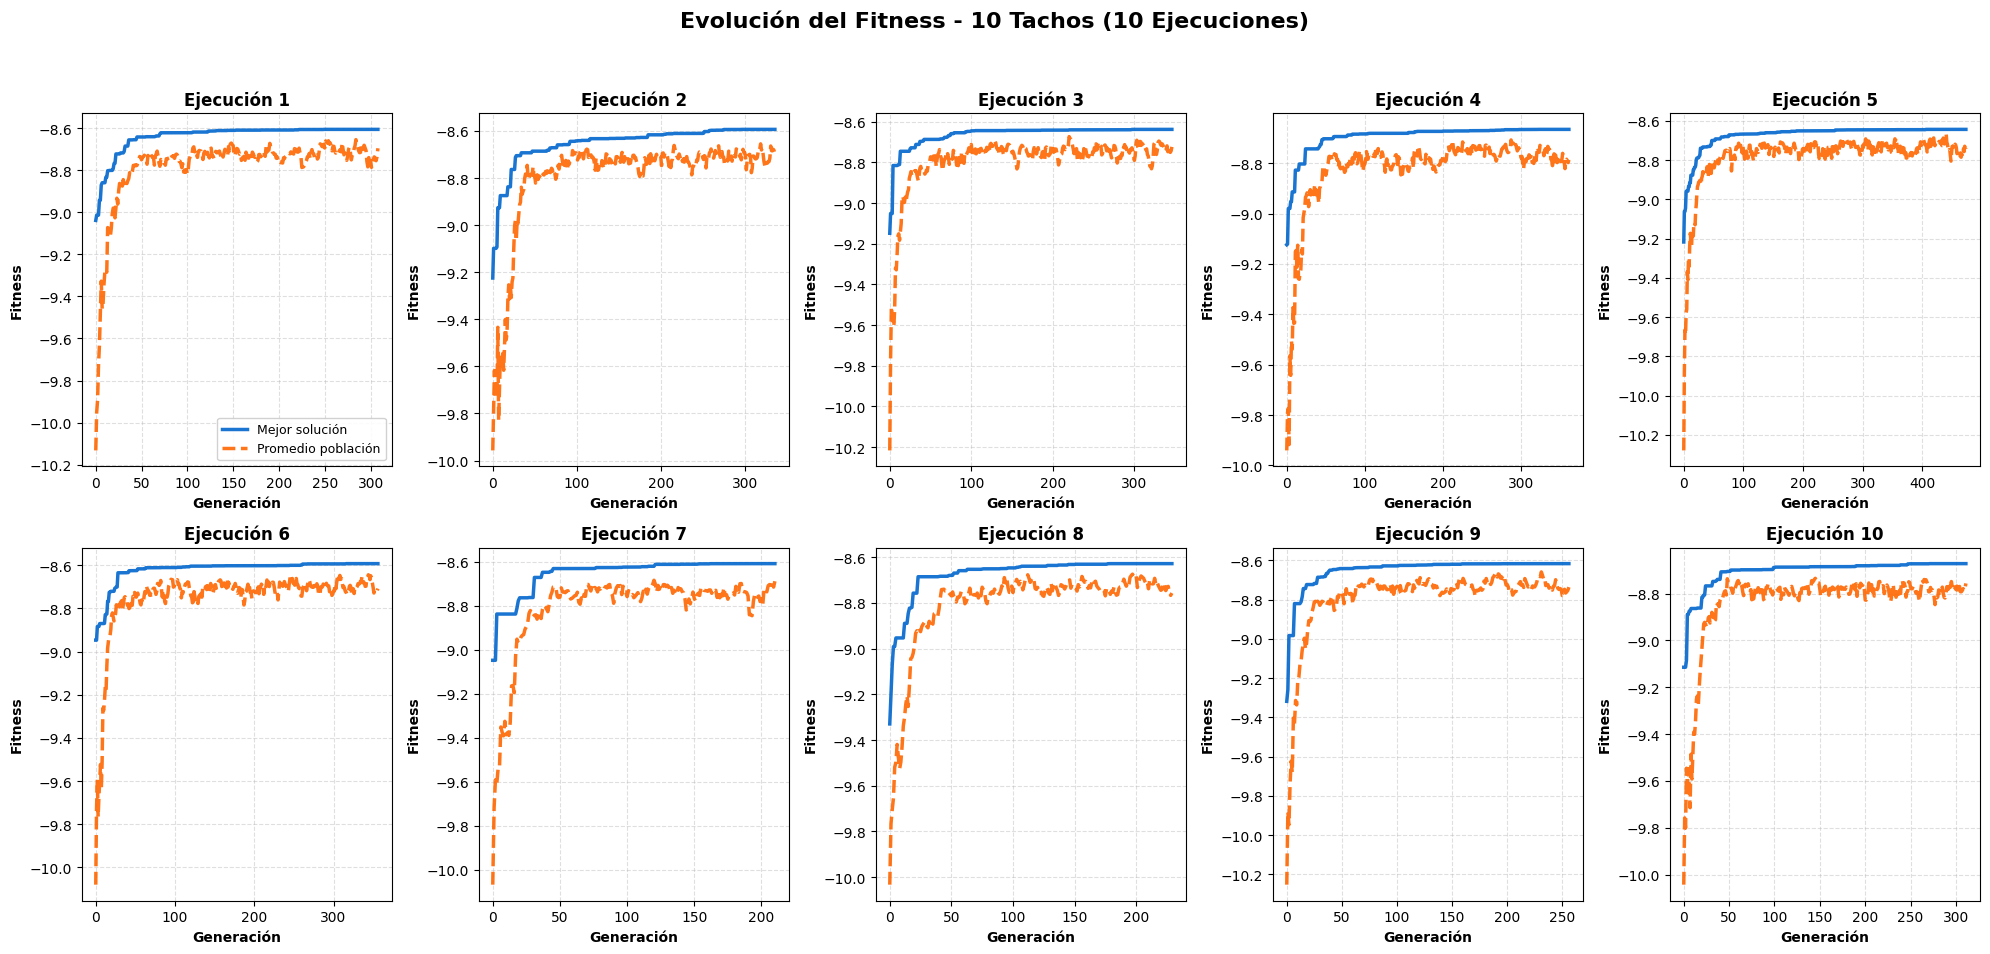

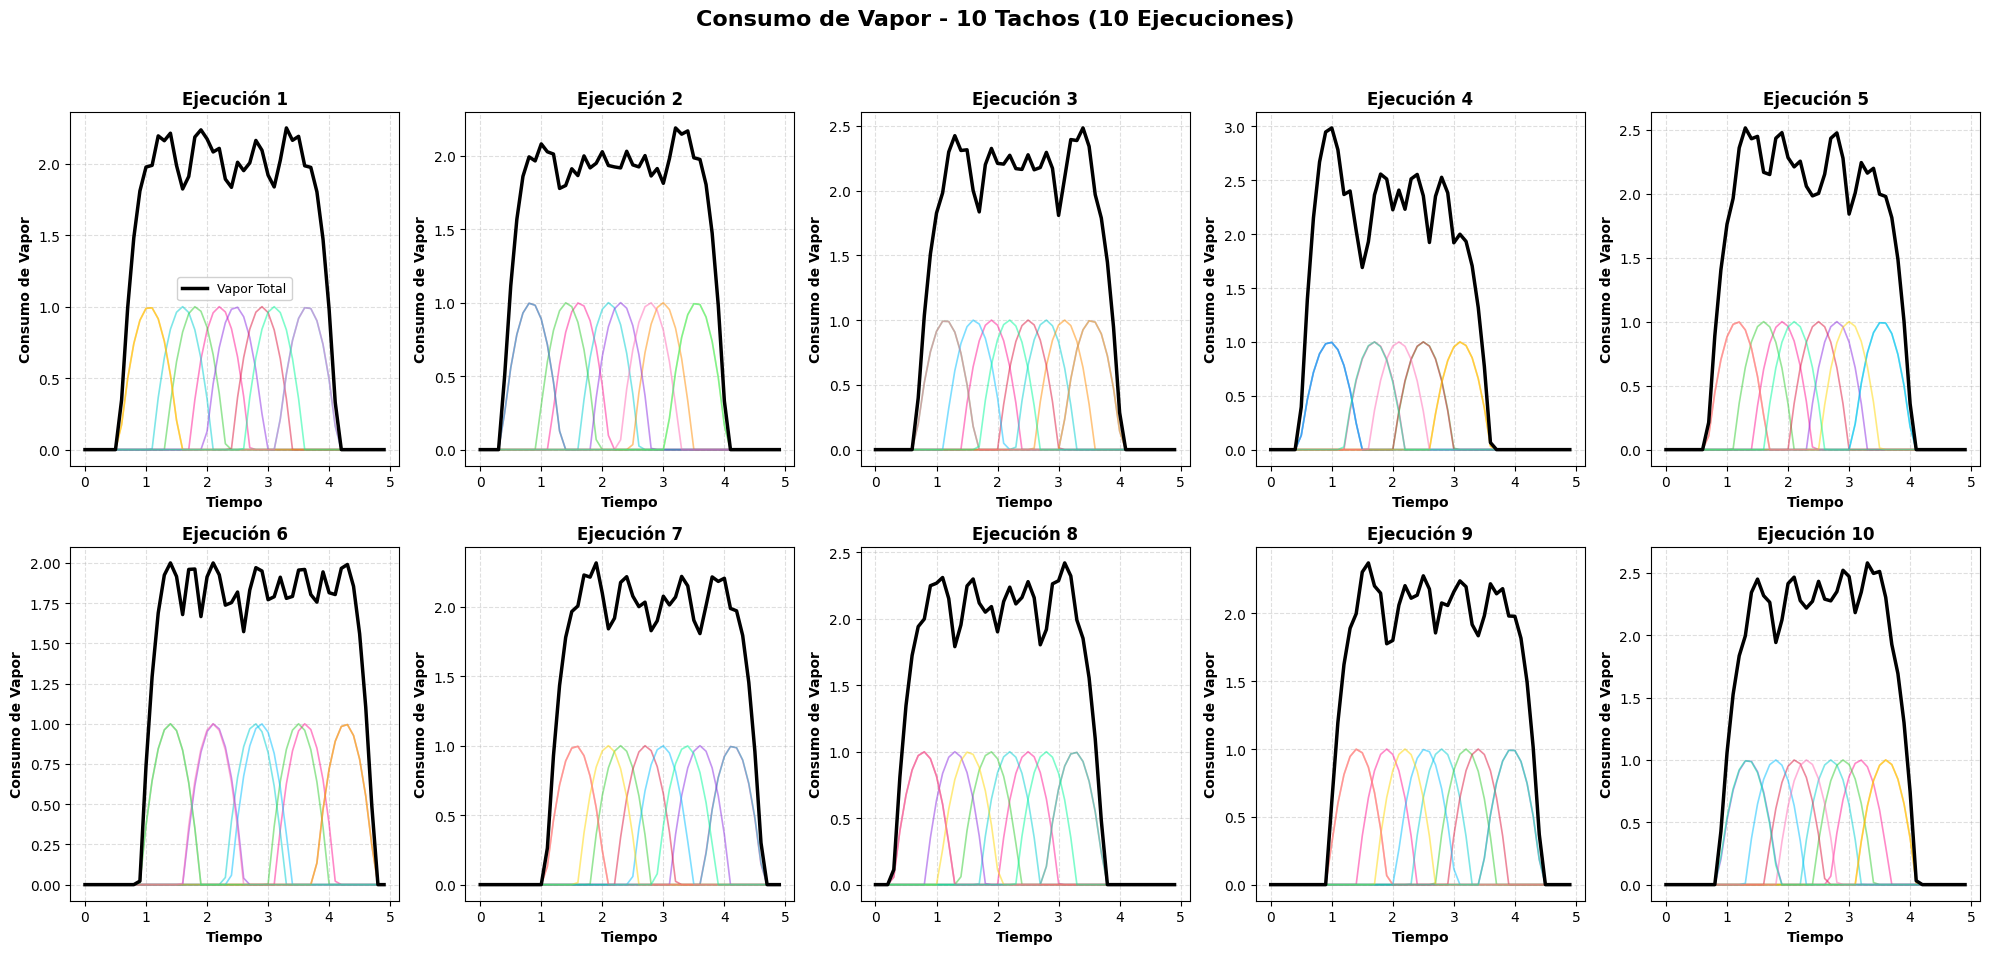


📊 Generando gráficos para 15 tachos...


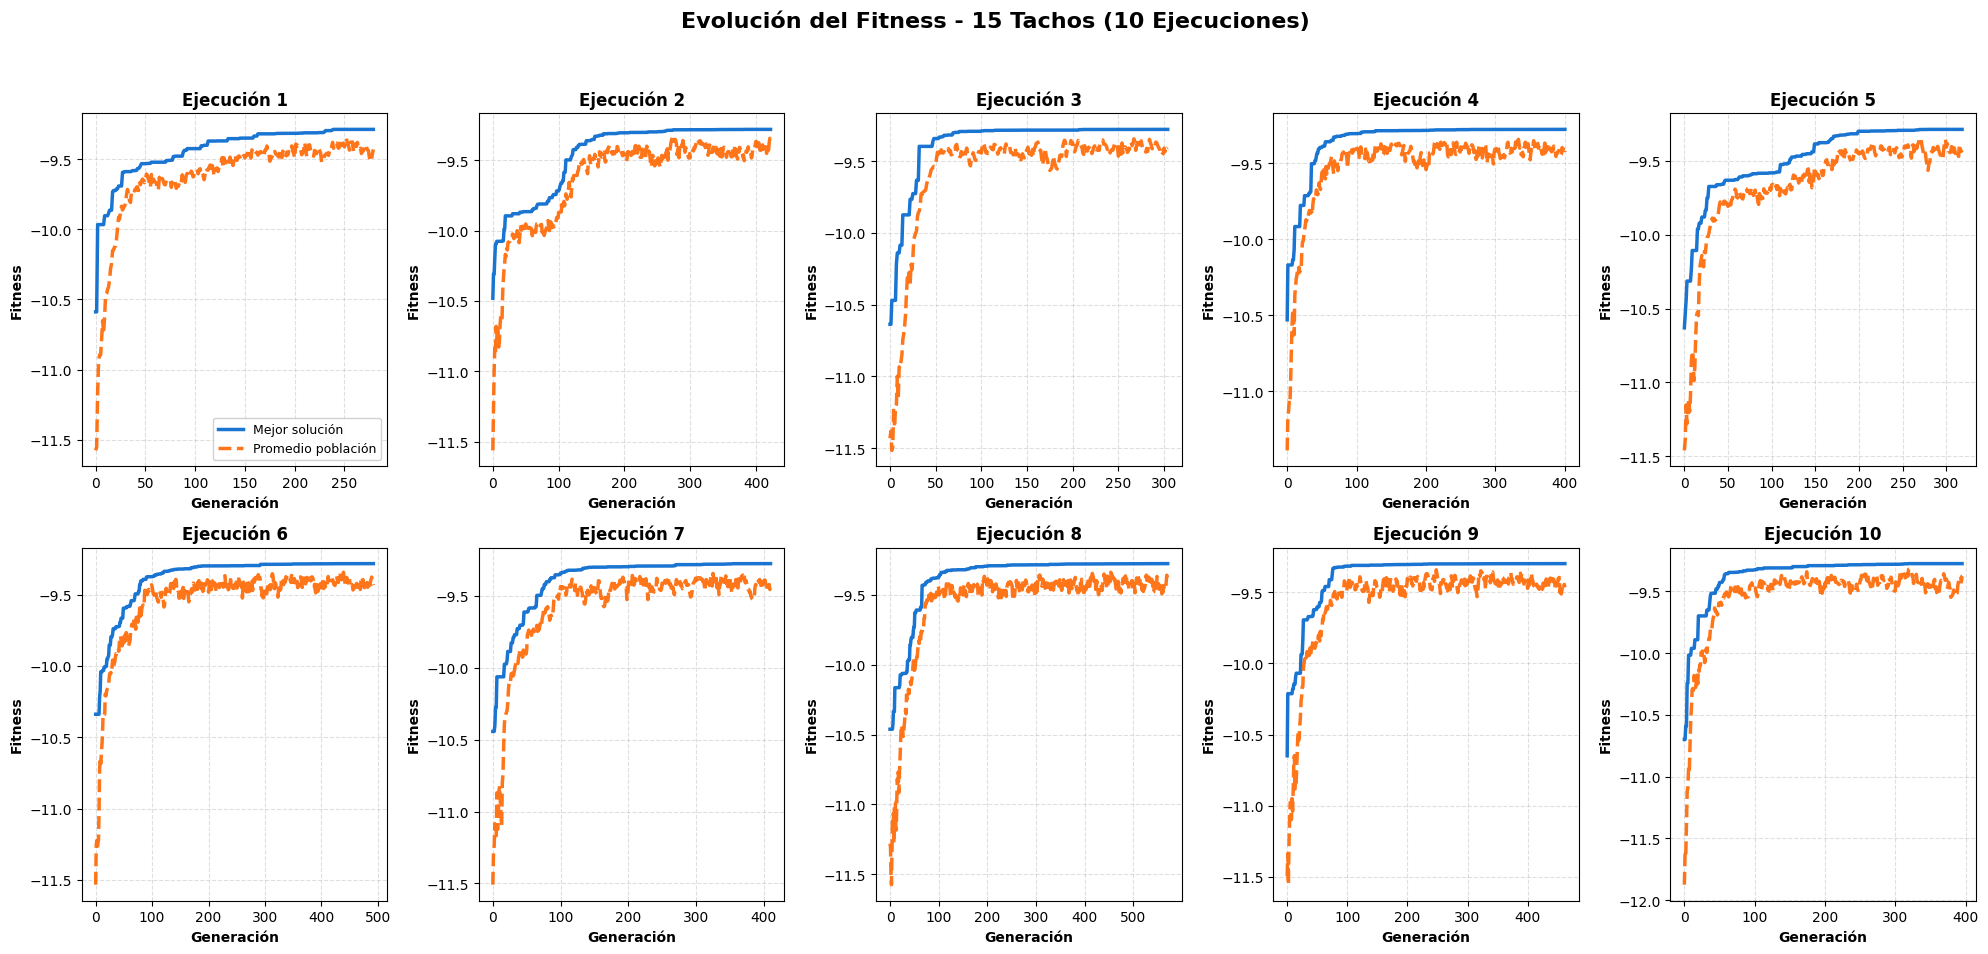

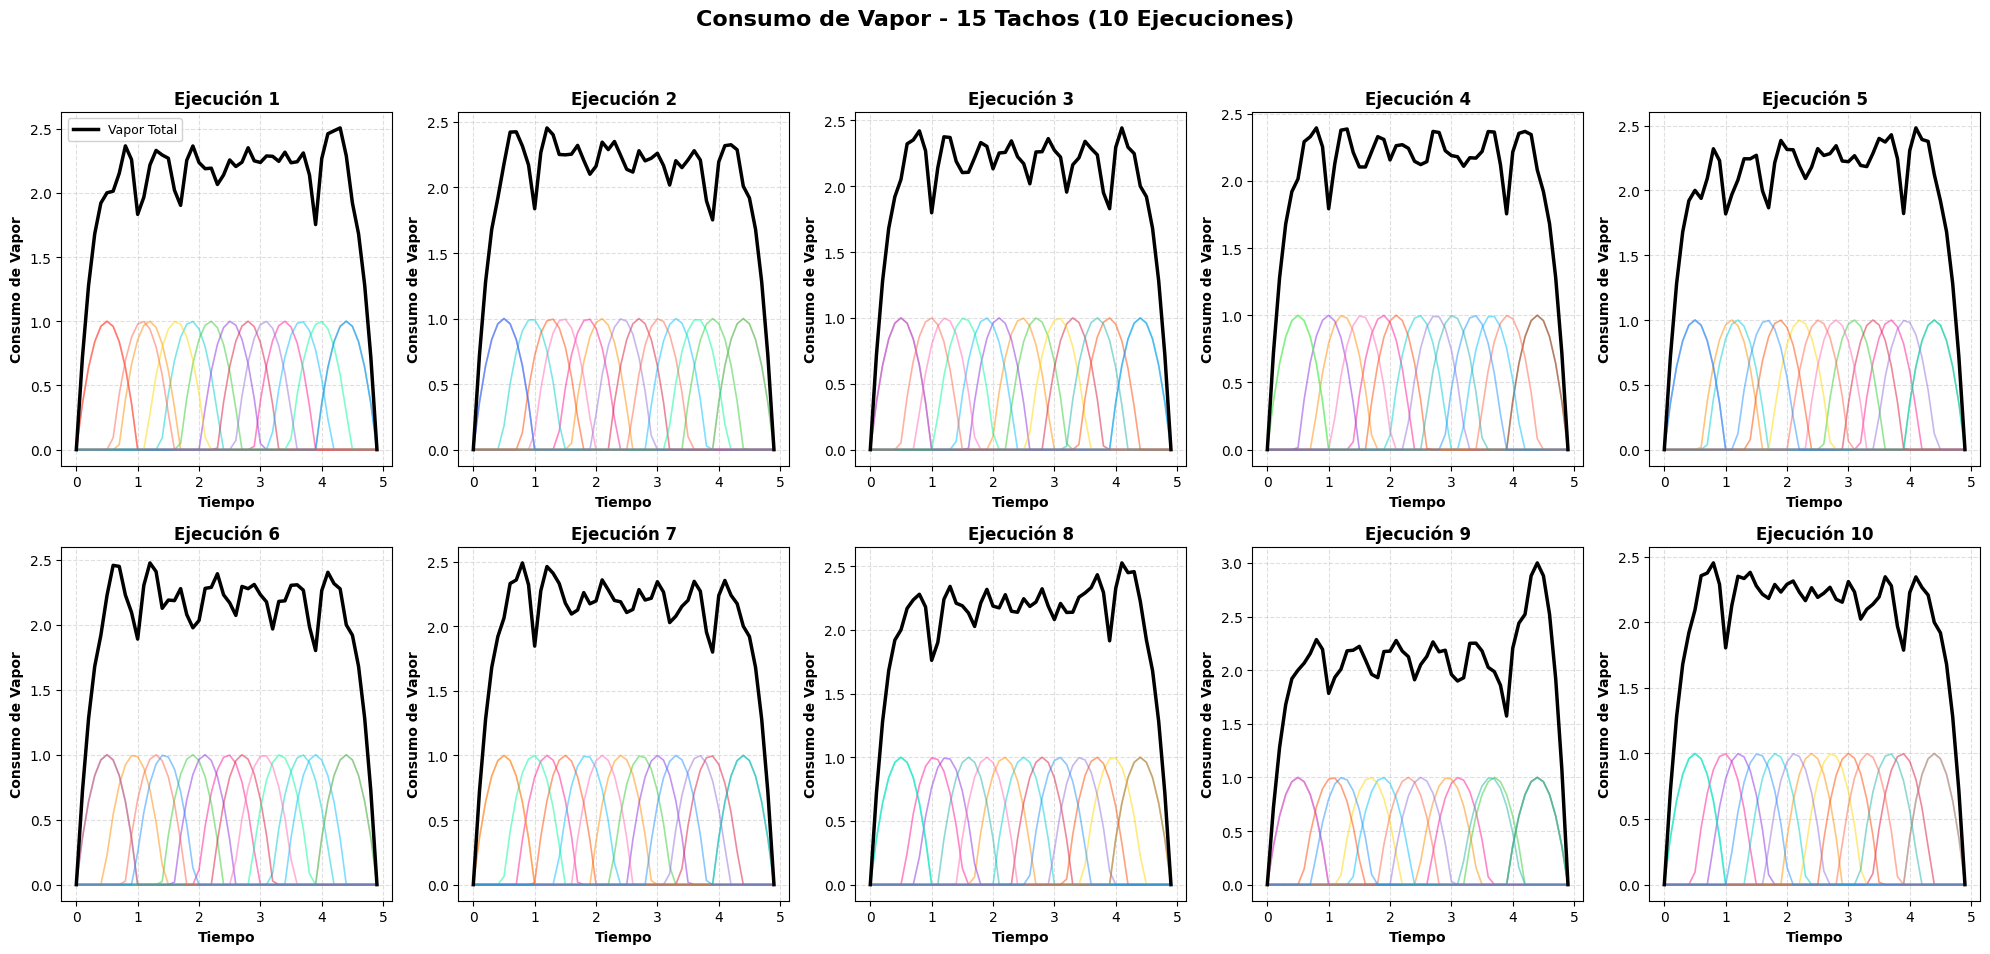


📊 Generando gráficos para 20 tachos...


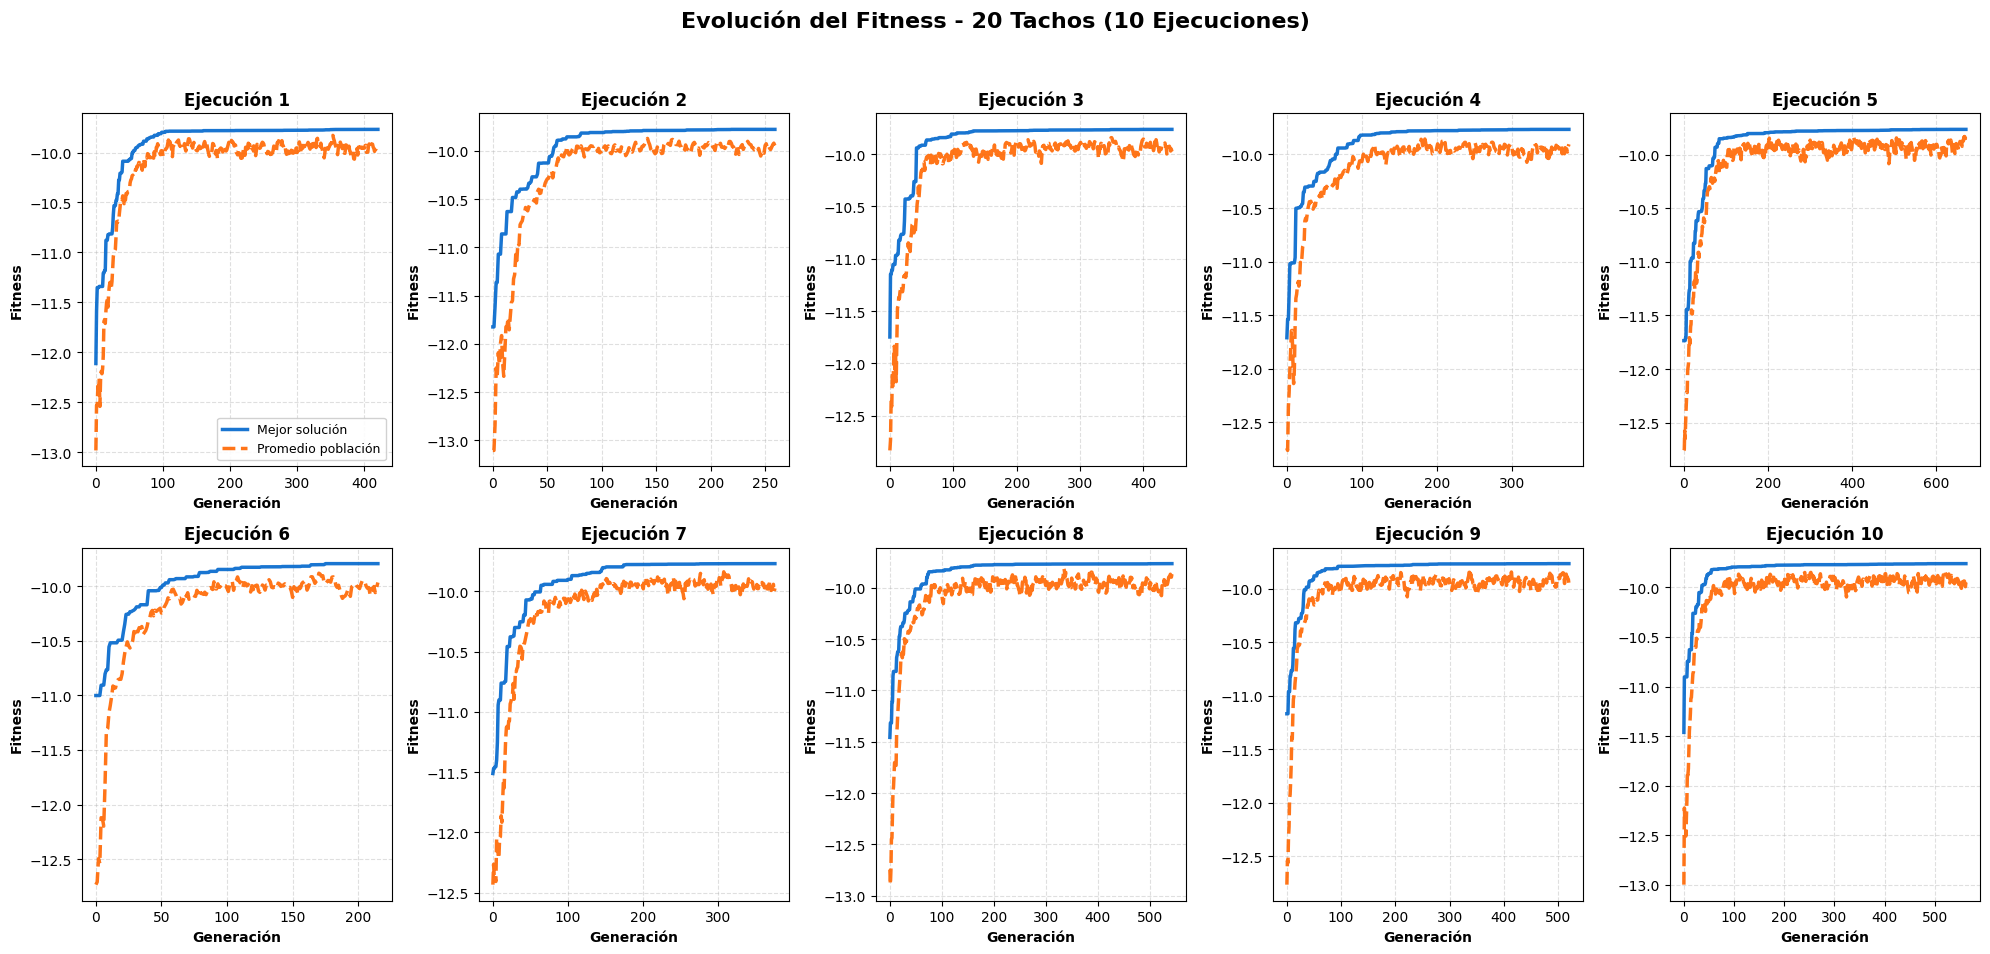

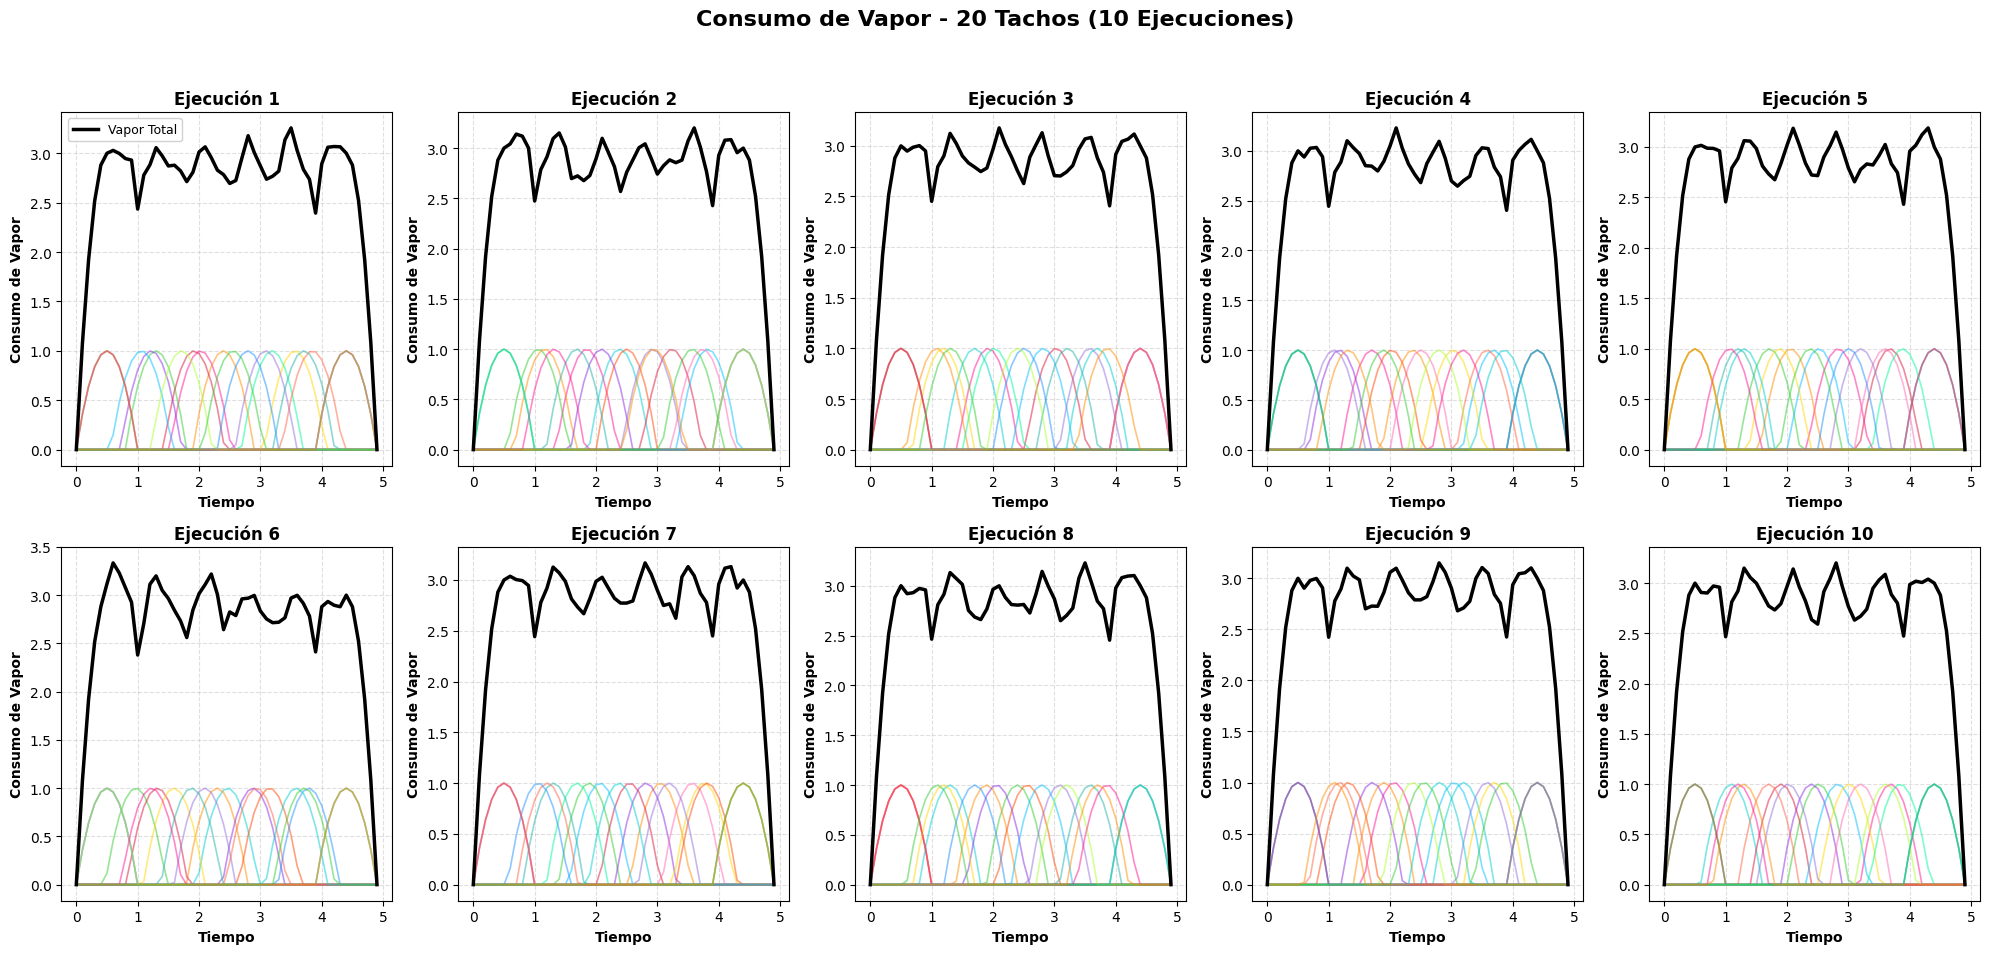

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración: diferentes cantidades de tachos
cantidades_tachos = [5, 10, 15, 20]
n_veces = 10  # Número de ejecuciones por cantidad de tachos

# Diccionario para almacenar resultados por cantidad de tachos
resultados_por_cantidad = {}

# Ejecutar para cada cantidad de tachos
for num_tachos_actual in cantidades_tachos:
    print("\n" + "="*80)
    print(f"  EJECUTANDO PARA {num_tachos_actual} TACHOS")
    print("="*80)

    # Configurar para esta cantidad de tachos
    intervalo_actual = [x/10 for x in range(50)]
    limiteSuperior_actual = max(intervalo_actual) - 1
    Bounds_actual = [[0, limiteSuperior_actual] for _ in range(num_tachos_actual)]
    Enteras_actual = [False] * num_tachos_actual

    cant_generac_actual = cant_generac
    cant_individuos_actual = cant_individuos
    cant_cruzados_actual = cant_cruzados
    cant_elite_actual = cant_elite
    cant_mutados_actual = cant_mutados

    # Listas para almacenar resultados de esta cantidad
    all_soluciones = []
    all_solF = []
    all_traces_best = []
    all_traces_avg = []
    all_bestSols = []

    # Ejecutar 10 veces para esta cantidad de tachos
    for i in range(n_veces):
        print(f"\n  Ejecución {i+1}/{n_veces} para {num_tachos_actual} tachos...")

        # Inicializar población
        Pop = init_pop_tachos(cant_individuos_actual, num_tachos_actual, Bounds_actual)

        # Ejecutar AG
        sol, solF, Pop_final, Fit_final, traceBest, traceAvg, bestSols = \
            geneticoSimple_Tachos(Pop, cant_generac_actual, Bounds_actual, Enteras_actual,
                                 sel, xover, mut, cant_cruzados_actual, cant_mutados_actual,
                                 cant_elite_actual, eps, fitnessTachos, intervalo_actual,
                                 mut2=mut2, porcentaje_mut1=porcentaje_mut1,
                                 porcentaje_mut2=porcentaje_mut2,
                                 xover2=xover2, porcentaje_xover1=porcentaje_xover1,
                                 porcentaje_xover2=porcentaje_xover2, callback=callback)

        # Calcular métricas
        variabilidad = calcular_variabilidad_vapor(sol, intervalo_actual)
        timespan = calcular_timespan(sol)

        # Almacenar resultados
        all_soluciones.append(sol)
        all_solF.append(solF)
        all_traces_best.append(traceBest)
        all_traces_avg.append(traceAvg)
        all_bestSols.append(bestSols)

    # Guardar resultados para esta cantidad de tachos
    resultados_por_cantidad[num_tachos_actual] = {
        'soluciones': all_soluciones,
        'solF': all_solF,
        'traces_best': all_traces_best,
        'traces_avg': all_traces_avg,
        'bestSols': all_bestSols,
        'intervalo': intervalo_actual
    }

    print(f"\n✅ Completadas {n_veces} ejecuciones para {num_tachos_actual} tachos")

# Función para graficar evolución de fitness en subplots
def plot_fitness_subplots(traces_best, traces_avg, num_executions, num_tachos):
    """Genera un plot con subplots de evolución del fitness para todas las ejecuciones."""
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    fig.suptitle(f'Evolución del Fitness - {num_tachos} Tachos (10 Ejecuciones)',
                 fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i in range(num_executions):
        ax = axes[i]
        x = range(len(traces_best[i]))
        ax.plot(x, traces_best[i], label='Mejor solución',
               color='#0066CC', linewidth=2.5, alpha=0.9)
        ax.plot(x, traces_avg[i], label='Promedio población',
               color='#FF6600', linewidth=2.5, linestyle='--', alpha=0.9)
        ax.set_title(f'Ejecución {i+1}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Generación', fontsize=10, fontweight='bold')
        ax.set_ylabel('Fitness', fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.4, linestyle='--')
        if i == 0:
            ax.legend(fontsize=9, framealpha=0.9)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Función para graficar tachos en subplots
def plot_tachos_subplots(soluciones, intervalo, num_executions, num_tachos):
    """Genera un plot con subplots de consumo de vapor para todas las ejecuciones."""
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    fig.suptitle(f'Consumo de Vapor - {num_tachos} Tachos (10 Ejecuciones)',
                 fontsize=16, fontweight='bold')
    axes = axes.flatten()

    # Colores vibrantes para los tachos individuales
    colores_tachos = ['#FF1493', '#00CED1', '#32CD32', '#FF8C00', '#8A2BE2',
                      '#DC143C', '#00BFFF', '#FFD700', '#FF69B4', '#00FA9A',
                      '#FF4500', '#9370DB', '#20B2AA', '#FF6347', '#1E90FF',
                      '#ADFF2F', '#FF1493', '#00CED1', '#32CD32', '#FF8C00']

    for ejec_num in range(num_executions):
        ax = axes[ejec_num]
        solucion = soluciones[ejec_num]

        # Graficar cada tacho con colores vibrantes
        for i, t0 in enumerate(solucion):
            vapor_tacho = [VaporTacho_i(t, t0) for t in intervalo]
            color = colores_tachos[i % len(colores_tachos)]
            ax.plot(intervalo, vapor_tacho, color=color, alpha=0.5, linewidth=1.2)

        # Graficar vapor total con color muy llamativo
        vapor_total = VaporTotal(solucion, intervalo)
        ax.plot(intervalo, vapor_total, color='#000000', linewidth=2.5,
               label='Vapor Total', zorder=10)

        ax.set_title(f'Ejecución {ejec_num + 1}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Tiempo', fontsize=10, fontweight='bold')
        ax.set_ylabel('Consumo de Vapor', fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.4, linestyle='--')
        if ejec_num == 0:
            ax.legend(fontsize=9, framealpha=0.9)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Generar gráficos con subplots para cada cantidad de tachos
print("\n" + "="*80)
print("GENERANDO GRÁFICOS CON SUBPLOTS PARA CADA CANTIDAD DE TACHOS")
print("="*80)

for num_tachos_actual in cantidades_tachos:
    datos = resultados_por_cantidad[num_tachos_actual]
    print(f"\n📊 Generando gráficos para {num_tachos_actual} tachos...")

    # Gráfico de fitness
    plot_fitness_subplots(datos['traces_best'], datos['traces_avg'], n_veces, num_tachos_actual)

    # Gráfico de tachos
    plot_tachos_subplots(datos['soluciones'], datos['intervalo'], n_veces, num_tachos_actual)

# 📋 Resumen Ejecutivo - Solución del Problema de Tachos

## 🎯 Objetivo del Problema

Optimizar el cronograma de arranque de **N tachos** (5-20) para:
- ✅ **Estabilizar el consumo de vapor** (evitar variaciones grandes)
- ✅ **Minimizar el tiempo total** del proceso
- ✅ **Evitar soluciones triviales** (todos juntos o secuenciales)

---

## 1️⃣ Codificación de Soluciones

**Representación:** Cada solución es un vector de tiempos de arranque `[t0₁, t0₂, ..., t0ₙ]`

**Ejemplo:** `[0.5, 1.2, 0.8]` significa que el tacho 1 arranca en t=0.5, el tacho 2 en t=1.2, etc.

**Ventaja:** Simple, directa y funciona para cualquier cantidad de tachos.

---

## 2️⃣ Restricciones (Bounds)

**Límites:** Cada tacho puede arrancar entre `[0, limiteSuperior]`

**Razón:** Garantiza que todos los tachos completen su ciclo antes del final del proceso.

---

## 3️⃣ Función Fitness

La función evalúa qué tan buena es una solución combinando:

1. **Variabilidad del vapor** (peso: 3.5)
   - Mide qué tan constante es el consumo
   - Menor variabilidad = mejor

2. **Tiempo total** (peso: 1.5)
   - Mide la duración del proceso completo
   - Menor tiempo = mejor

3. **Penalización por soluciones triviales** (5.0)
   - Detecta si todos arrancan juntos o secuencialmente
   - Aplica penalización fuerte para rechazarlas

**Resultado:** Fitness más alto = mejor solución

---

## 4️⃣ Algoritmo Genético

**Tipo:** Algoritmo Genético Simple con Elitismo

**Operadores elegidos:**
- **Selección:** SUS (Stochastic Universal Sampling)
- **Cruzamiento:** 95% Uniform CrossOver + 5% BLX-α 
- **Mutación:** 60% Polynomial + 40% Gaussiana  

**Por qué funciona:** Los operadores están especializados para variables continuas, no para permutaciones.

---

## 5️⃣ Parámetros Configurados

| Parámetro | Valor | Motivo |
|-----------|-------|--------|
| Población | 20 | Balance diversidad/costo |
| Generaciones | 1000 | Suficiente para convergencia |
| Cruzamiento | 70% | Alta exploración |
| Mutación | 20% | Mantiene diversidad |
| Elite | 1 | Preserva mejores soluciones |


---

## ✅ Ventajas de la Solución

1. **Cumple todos los objetivos** del enunciado
2. **Operadores adecuados** para el tipo de problema (continuas)
3. **Escalable** - funciona para 5 a 20 tachos
4. **Robusto** - evita soluciones triviales automáticamente
5. **Validado** - parámetros basados en mejores prácticas

---

## 📊 Resultados Esperados

- Soluciones que **distribuyen los arranques** para mantener vapor constante
- Tiempos totales **razonables** (no mínimos triviales)
- **Convergencia estable** y predecible

---

## 💡 Recomendaciones de Uso

- Ejecutar **10 veces** y elegir la mejor solución
- Ajustar pesos de fitness según prioridades (más estabilidad vs. menos tiempo)
- Revisar gráficos para validar que no sean soluciones triviales

---

*Solución implementada con enfoque en calidad, robustez y cumplimiento de todos los requisitos.*


## Conclusión

A pesar de que la solución obtenida no da un óptimo global, nos da una solución que cumple con todos los requisitos del problema y se mantiene estable en la mayoria de las ejecuciones.

Este problema nos ayudó a poner en practica todo lo aprendido en la materia, o al menos la mayoría. Nos hizo aprender a romper todo y volver a empezar casi desde cero. Nos hizo entender que operadores de cruzamiento y mutacion pueden llegar a ser beneficiosos y en la justa medida del mismo. 